<a href="https://colab.research.google.com/github/aggrimm/IEDRR_inland_lakes/blob/main/notebooks/2_nhd_addressing_inc_test_junk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



*   Uses outputs from 1_get_spp_data
*   Snap AIS observations to the nearest NHD flowline
*   Trace all of the observations in lakes upstream
*   Count how many species are present upstream
*   Get the distance to the closest one







In [ ]:
# If this cell fails, restart session and run again
!pip install pynhd
import pynhd
from pynhd import NLDI, WaterData, NHDPlusHR, NHD, HP3D


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.4/51.4 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.5/240.5 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.6/69.6 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 61.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.7/70.7 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.8/223.8 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 34.3 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0


In [ ]:
%%capture
!pip install swifter
import swifter

import math

import pandas as pd
import geopandas as gpd
import folium
import matplotlib
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np

import shapely
import shapely.geometry as sgeom
from shapely.geometry import Point
from shapely.ops import nearest_points
from pyproj import CRS

!pip install mapclassify
import mapclassify

from google.colab import drive
drive.mount('/content/drive')
import os
os.chdir("drive/My Drive/iedrr")
import time
from timeit import default_timer as timer

from tqdm import tqdm
# Enable the progress_apply method in Pandas
tqdm.pandas()

obs = {}
my_vars = ['fish', 'plant', 'invert']
rad = 500

In [ ]:
pdate = '20260208'

In [ ]:
!pip install geojsplit
from geojsplit import geojsplit
geojson = geojsplit.GeoJSONBatchStreamer("NHDWaterbody_V2_LakePondReservoir_GLStates.json")


  Preparing metadata (setup.py) ... done
  Created wheel for ijson: filename=ijson-2.6.1-py3-none-any.whl size=17424 sha256=bbbf2dc43a48e7ec194f5bcc4b4a9af982d026f17f8c821cb9684b314b208cc3
  Stored in directory: /root/.cache/pip/wheels/49/72/79/4978bc26ec1db8bc5fe15e54f5750d52b33327c7a43573238f
Successfully built ijson


In [ ]:
# get outlet flowline comid and sorted list of upstream flowlines for all lakes
# this should only need to be run again if the nhd has changed, otherwise skip to next cell

nhd = WaterData("nhdflowline_network")
nldi = NLDI()
outfile = '/content/drive/MyDrive/iedrr/lake_connectivity.csv'

chk = 0

def lakesegs(row):
  try:
    id_int = int(row['Permanent_'])
    #print('Permanent_: ', id_int)
    row['Permanent_'] = id_int
    main_nhd = nhd.byid("wbareacomi", id_int) # get df of flowline segments in the lake
    row['lake_segs'] = main_nhd['comid'].tolist() # list of lake flowline comids
    main_nhd = pynhd.prepare_nhdplus(main_nhd, 0, 0, 0)
    # sort the segments from upstream to downstream
    main_nhd_sort = pynhd.topoogical_sort(main_nhd, edge_attr=None, largest_only=False, id_col='comid', toid_col='tocomid') # no, it isn't topological_sort
    out_comid = abs(main_nhd_sort[0][-1])
    row['out_comid'] = out_comid
    #print('out_comid: ', out_comid)
  except Exception as e:
    #print(e)
    row['out_comid'] = None
    row['lake_segs'] = None
    row['upsegs'] = None
  if row['out_comid']:
    try:
      # get list of upstream comids for lake
      utribs = nldi.navigate_byid(
          fsource="comid",
          fid=int(row['out_comid']),
          navigation="upstreamTributaries",
          source="flowlines"
          )
      # get list of comids in traced tributaries
      flw_ids = utribs['nhdplus_comid'].unique() # strings
      flw_prep = nhd.byid("comid", flw_ids.tolist())
      flw_prep.loc[flw_prep.comid == int(row.out_comid), ['terminalfl']] = 1 # prevent errors
      utribs = pynhd.prepare_nhdplus(flw_prep, 0, 0, 0, terminal2nan = True)
      # sort the segments from upstream to downstream
      utribs_sort = pynhd.topoogical_sort(utribs, edge_attr=None, largest_only=False, id_col='comid', toid_col='tocomid')
      # drop the segments that are actually in the lake to keep just the ones that are upstream
      set2 = set(row['lake_segs'])
      fsegs = [x for x in utribs_sort[0] if abs(x) not in set2]
      row['upsegs'] = fsegs
      #print('lake segs ', row['lake_segs'])
      #print('upsegs ', fsegs)
      #print('lake ', row['Permanent_'], 'out', row['out_comid'], 'upst_segs', len(fsegs))
    except Exception as e:
      #print(e)
      row['upsegs'] = None
  return row

if os.path.exists(outfile):
  done = pd.read_csv(outfile)
  chk_done = math.ceil(done.shape[0]/3000)
  print('done:',chk_done)
else:
  chk_done = 0

for chunk in geojson.stream(batch=3000):
  if chk < chk_done:
    chk = chk + 1
  else:
    gdf_lks = gpd.GeoDataFrame.from_features(chunk["features"], crs='epsg:4326')
    gdf_lks = gdf_lks.swifter.apply(lakesegs, axis=1)
    with open(outfile, 'a') as f:
      gdf_lks.to_csv(f, mode='a', index=False, header=f.tell()==0)

# fixing

# get outlet flowline comid and sorted list of upstream flowlines for all lakes
# this should only need to be run again if the nhd has changed

orig = gpd.read_file('NHDWaterbody_V2_LakePondReservoir_GLStates.json')

nhd = WaterData("nhdflowline_network")
nldi = NLDI()
outfile = '/content/drive/MyDrive/iedrr/lake_connectivity.csv'

# fix csv formatting
lake_conn = pd.read_csv(outfile)

for i, row in lake_conn.iterrows():
  upsegs = row['upsegs']
  if pd.isnull(upsegs):
    lake_conn.at[i, 'upsegs'] = None
  elif row['upsegs'] == '[]':
    lake_conn.at[i, 'upsegs'] = None
  else:
    try:
      upsegs = upsegs[1:-1].split(', ')
      upsegs = list(map(lambda x: x.replace('np.int64(','').replace(')','').replace('nan','None'),upsegs))
      upsegs = list(map(int, upsegs))
      lake_conn.at[i, 'upsegs'] = upsegs
    except:
      print(i)
      #row = None
print('done')



done: 23


Pandas Apply:   0%|          | 0/3000 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/3000 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/3000 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/809 [00:00<?, ?it/s]

done


In [ ]:
# fixing

# get outlet flowline comid and sorted list of upstream flowlines for all lakes
# this should only need to be run again if the nhd has changed

orig = gpd.read_file('NHDWaterbody_V2_LakePondReservoir_GLStates.json')

nhd = WaterData("nhdflowline_network")
nldi = NLDI()
outfile = '/content/drive/MyDrive/iedrr/lake_connectivity.csv'

# fix csv formatting
lake_conn = pd.read_csv(outfile)

for i, row in lake_conn.iterrows():
  upsegs = row['upsegs']
  if pd.isnull(upsegs):
    lake_conn.at[i, 'upsegs'] = None
  elif row['upsegs'] == '[]':
    lake_conn.at[i, 'upsegs'] = None
  else:
    try:
      upsegs = upsegs[1:-1].split(', ')
      upsegs = list(map(lambda x: x.replace('np.int64(','').replace(')','').replace('nan','None'),upsegs))
      upsegs = list(map(int, upsegs))
      lake_conn.at[i, 'upsegs'] = upsegs
    except:
      print(i)
      #row = None

In [ ]:
# updated
# flag obs that are within [rad] m of an NHD MR waterbody and grab comid of nearest waterbody
# get snap coordinates for lake outlet

obs = {}
###################
# is there a lake within 500 m of obs, what is the id of the lake
for k in my_vars:
  out_df=[]
  #outfile = os.path.join(cwd, k + '_obs_allsources_' + datetime.date.today().strftime('%Y%m%d') + '.csv')
  outfile = '/content/drive/MyDrive/iedrr/speciesobs_'+pdate+'/'+k+'_obs_allsources_states'+pdate+'.csv'
  df = pd.read_csv(outfile)
  gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df['lon_dec'], df['lat_dec']), crs="EPSG:4326")
  utm = gdf.estimate_utm_crs()
  cnum = 0
  for chunk in geojson.stream(batch=1000):
    gdf_lks = gpd.GeoDataFrame.from_features(chunk["features"], crs='epsg:4326')
    # find lakes within radius
    gdfu = gdf.to_crs(utm)
    gdflksu = gdf_lks.to_crs(utm)
    sj = gpd.sjoin_nearest(left_df= gdfu, right_df=gdflksu, max_distance=rad, how="left",  distance_col="distances")
    # keep cumulative minimum distance to lake
    outs = sj[["uid", "Permanent_", "distances"]]
    out_df.append(outs)
    print(k, cnum)
    cnum = cnum + 1
  print(k, 'complete')
  out_df = pd.concat(out_df, ignore_index=True)
  # Keep only the rows with the minimum distance
  #result = out_df.groupby('uid')['distances'].min(skipna=True)
  result=out_df.loc[out_df.groupby('uid')['distances'].idxmin().dropna()]
  # join ID of nearest lake back to obs
  df = pd.merge(df, result, on="uid", how="left")

  obs[k] = df
  # output: "uid", "Permanent_", "ReachCode", "distances"


NameError: name 'geojson' is not defined

In [ ]:
# how many invaded lakes?
for t in my_vars:
  print(t)
  print(obs[t]['Permanent_'].nunique())
  print(obs[t]['Permanent_'].isnull().sum())

fish
344
6081
plant
1600
21554
invert
1607
6240


In [ ]:
newobs = {}
# join lake outlet flowlines based on lake id
lake_lines = '/content/drive/MyDrive/iedrr/lake_connectivity.csv'
lake_lines = pd.read_csv(lake_lines)
lake_lines['Permanent_'] = lake_lines['Permanent_'].astype(str)
lake_lines = lake_lines[['Permanent_', 'out_comid']]
for k in my_vars:
  # drop all but the first obs of a species in a lake, keep all obs not in lakes
  obs[k] = obs[k].sort_values('obs_date')
  #df = obs[k].drop_duplicates(subset=['sci_name', 'Permanent_'], keep='first').append(obs[k][obs[k]['Permanent_'].isna()])
  df=obs[k][obs[k]['Permanent_'].isnull() | ~obs[k][obs[k]['Permanent_'].notnull()].duplicated(subset=['sci_name', 'Permanent_'],keep='first')]
  #obs[k] = obs[k][(~obs[k].duplicated(subset=['sci_name', 'Permanent_'], keep='first')) | obs[k]['Permanent_'].isna()]
  newobs[k] = pd.merge(df, lake_lines, on="Permanent_", how="left")

# snap lake obs to most downstream point of lake outlet flowline
nhd = WaterData("nhdflowline_network")

def lakesegs(row):
  # if obs is near a lake with an artificial flowline
  if pd.notnull(row['out_comid']):
    try:
      id_int = int(row['Permanent_'])
      # get last point in most downstream segment
      lakeout = nhd.byid("comid", row['out_comid'])
      coordinates_df = lakeout.geometry.get_coordinates()  # Get all coordinates as a DataFrame
      last_coordinate = coordinates_df.iloc[-1]
      # move point to coordinates
      row['snap_lon'] = last_coordinate['x']
      row['snap_lat'] = last_coordinate['y']
      print('lake ', row['Permanent_'], 'lon', row['snap_lon'])
    except:
      row['snap_lon'] = None
      row['snap_lat'] = None
  else:
    row['snap_lon'] = None
    row['snap_lat'] = None
  return row

for k in my_vars:
  df = newobs[k]
  count_non_null = df['Permanent_'].count()
  print(f"{count_non_null} lakes to process for {k}")
  # find the flowline segments within each lake
  df = df.swifter.apply(lakesegs, axis=1)
  newobs[k] = df
  outfile = '/content/drive/MyDrive/iedrr/speciesobs_'+pdate+'/'+k+'_obs_allsources_lakeflag_test_'+pdate+'.csv'
  df.to_csv(outfile, index=False)
  print(k, 'complete')



/tmp/ipython-input-3852465758.py:11: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df=obs[k][obs[k]['Permanent_'].isnull() | ~obs[k][obs[k]['Permanent_'].notnull()].duplicated(subset=['sci_name', 'Permanent_'],keep='first')]
/tmp/ipython-input-3852465758.py:11: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df=obs[k][obs[k]['Permanent_'].isnull() | ~obs[k][obs[k]['Permanent_'].notnull()].duplicated(subset=['sci_name', 'Permanent_'],keep='first')]
/tmp/ipython-input-3852465758.py:11: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df=obs[k][obs[k]['Permanent_'].isnull() | ~obs[k][obs[k]['Permanent_'].notnull()].duplicated(subset=['sci_name', 'Permanent_'],keep='first')]


370 lakes to process for fish


Pandas Apply:   0%|          | 0/6451 [00:00<?, ?it/s]

fish complete
2037 lakes to process for plant


Pandas Apply:   0%|          | 0/23591 [00:00<?, ?it/s]

plant complete
1897 lakes to process for invert


Pandas Apply:   0%|          | 0/8137 [00:00<?, ?it/s]

invert complete


In [ ]:
# identify obs within the specified radius of a flowline but not a lake
mr = WaterData("nhdflowline_network")

def nearsegs(row):
  if pd.isnull(row['Permanent_']):
    try:
      coords = row['lon_dec'], row['lat_dec']
      flw_rad = mr.bydistance(coords, rad) # rad is in meters even if crs is geographic
      row['flw'] = True
    except:
      row['flw'] = False
  else:
    row['flw'] = False
  return row

# process in chunks and append to csv because this takes f o r e v e r
start = timer()

for k in my_vars:
  chk = 0
  #df = obs[k]
  infile = '/content/drive/MyDrive/iedrr/speciesobs_'+pdate+'/'+k+'_obs_allsources_lakeflag_test_'+pdate+'.csv'
  outfile = '/content/drive/MyDrive/iedrr/speciesobs_'+pdate+'/'+k+'_obs_allsources_flagged_'+pdate+'.csv'
  outdf = []
  if os.path.exists(outfile):
    dfex = pd.read_csv(outfile)
    chk_done = math.ceil(dfex.shape[0]/5000)
    print('chk',chk_done)
    outdf.append(dfex)
  else:
    chk_done = 0
  for df_small in pd.read_csv(infile, chunksize=5000):
    if chk < chk_done:
      chk = chk + 1
    else:
      print(k,chk)
      df = df_small.swifter.apply(nearsegs, axis=1)
      with open(outfile, 'a') as f:
        df.to_csv(f, mode='a', index=False, header=f.tell()==0)
      outdf.append(df)
      chk = chk + 1
  print(k, 'complete')
  outdf = pd.concat(outdf, ignore_index=True)
  #df.to_csv(outfile, index=False)
  obs[k] = outdf

end = timer()
runtime = time.strftime('%H:%M:%S', time.gmtime(end - start))
print("runtime ",runtime)


chk 2
fish complete
chk 5
plant complete
invert 0


Pandas Apply:   0%|          | 0/5000 [00:00<?, ?it/s]

invert 1


Pandas Apply:   0%|          | 0/3137 [00:00<?, ?it/s]

invert complete
runtime  01:21:08


In [ ]:
nldi = NLDI()

DatabaseError: database disk image is malformed

In [ ]:
# snap the obs near flowlines
nldi = NLDI()

# if flw = True, snap obs to nearest flowline
def snapsegs(row):
  # if obs is near a flowline
  if row['flw'] == True:
    try:
      coords = (row['lon_dec'], row['lat_dec'])
      comid_closest = nldi.comid_byloc(coords, "EPSG:4326")
      point_row = comid_closest.iloc[0]
      measure = point_row['measure']
      length = point_row['lengthkm']
      downlengthkm = measure*length
      row['snap_lon'] = point_row.geometry.x
      row['snap_lat'] = point_row.geometry.y
      row['top_comid'] = point_row['comid']
      row['measure'] = point_row['measure']
    except:
      row['snap_lon'] = None
      row['snap_lat'] = None
      row['top_comid'] = None
      row['measure'] = None

  return row


start = timer()

for k in my_vars:
  chk = 0
  #df = obs[k]
  infile = '/content/drive/MyDrive/iedrr/speciesobs_'+pdate+'/'+k+'_obs_allsources_flagged_'+pdate+'.csv'

  outfile = '/content/drive/MyDrive/iedrr/speciesobs_'+pdate+'/'+k+'_obs_allsources_snapped_'+pdate+'.csv'
  if os.path.exists(outfile):
    dfex = pd.read_csv(outfile)
    chk_done = math.ceil(dfex.shape[0]/3000)
    print('chk',chk_done)
  else:
    chk_done = 0
  for df_small in pd.read_csv(infile, chunksize=3000):
    if chk < chk_done:
      chk = chk + 1
    else:
      print(k,chk)
      gdf = gpd.GeoDataFrame(df_small, geometry=gpd.points_from_xy(df_small['lon_dec'], df_small['lat_dec']), crs="EPSG:4326")
      utm = gdf.estimate_utm_crs()
      gdf = gdf.swifter.apply(snapsegs, axis=1)
      with open(outfile, 'a') as f:
        gdf.to_csv(f, mode='a', index=False, header=f.tell()==0)
      chk = chk + 1

  print(k, 'complete')

end = timer()
runtime = time.strftime('%H:%M:%S', time.gmtime(end - start))
print("runtime ",runtime)

DatabaseError: database disk image is malformed

In [ ]:
# calculate stream dist to all upstream obs
# nldi comid_byloc measure column represents location of input coordinate as percentage of total flowline length
nldi = NLDI()
nhd = WaterData("nhdflowline_network")
nhdp_mr = WaterData("nhdflowline_network")

for k in my_vars:
  chk = 0
  infile = '/content/drive/MyDrive/iedrr/speciesobs_'+pdate+'/'+k+'_obs_allsources_snapped_'+pdate+'.csv'
  outfile = '/content/drive/MyDrive/iedrr/speciesobs_'+pdate+'/'+k+'_lakes_obsdists_'+pdate+'.csv'

  #all_obs_dists = []
  if os.path.exists(outfile):
    dfex = pd.read_csv(outfile)
    chk_done = math.ceil(dfex.shape[0]/3000)
    print('chk',chk_done)
  else:
    chk_done = 0

  for df_small in pd.read_csv(infile, chunksize=3000):
    obs_dists = []
    df_small['top_comid_str'] = df_small['top_comid'].astype('Int64').astype('str')

    outdf = []
    if chk < chk_done:
      chk = chk + 1
    else:
      print(k,chk)

    lakes = df_small[['Permanent_', 'top_comid']].dropna()
    lakes.drop_duplicates(inplace=True)


    #for i, row in lakes.iterrows():
    for i, row in tqdm(lakes.iterrows(), total=lakes.shape[0]):
      # dataframe of nhdplus_comid and
      #print('lake ', row['Permanent_'], row['top_comid'])

      try:
        utribs = nldi.navigate_byid(
            fsource="comid",
            fid=row['top_comid'].astype(int),
            navigation="upstreamTributaries",
            source="flowlines"
        )
        umain = nldi.navigate_byid(
            fsource="comid",
            fid=row['top_comid'].astype(int),
            navigation="upstreamMain",
            source="flowlines"
        )
      except Exception as e:
        print('error in utribs calc, lake', row['Permanent_'])
        print(e)
        continue
      # get list of comids in traced tributaries
      flw_ids = utribs['nhdplus_comid'].unique().tolist() + umain['nhdplus_comid'].unique().tolist() # strings
      flw_ids = list(set(flw_ids))

      # import lake table
      # flwids from lake table


      #print(len(flw_ids), "flowlines upstream")
      # how many species were snapped to flowlines upstream from the lake (all dates)
      #df_sp = df.loc[df['top_comid_str'].isin(flw_ids)]
      # drop the flowline we started from
      #df_sp = df_sp[df_sp['top_comid_str'] != str(int(row['top_comid']))]
      #row['up_spp'] = int(len(df_sp['sci_name'].unique()))
      #print(row['up_spp'], "spp upstream")
      # get flowlines
      try:
        flw_prep = nhd.byid("comid", flw_ids)
      except Exception as e:
        print('error in flw_prep calc, lake', row['Permanent_'])
        print(e)
        continue
      flw_prep.loc[flw_prep.comid == int(row.top_comid), ['terminalfl']] = 1 # prevent errors
      try:
        utribs = pynhd.prepare_nhdplus(flw_prep, 0, 0, 0, terminal2nan = True)
        # sort the segments from upstream to downstream
        utribs_sort = pynhd.topoogical_sort(utribs, edge_attr=None, largest_only=False, id_col='comid', toid_col='tocomid')
      except Exception as e:
        print('error sorting utribs, lake', row['Permanent_'])
        print(e)
        continue
      # get the ones coincident with obs
      utribs_sort_obs = utribs_sort[0]
      set2 = set(df_sp['top_comid'])
      utribs_sort_obs = [x for x in utribs_sort_obs if x in set2]
      #print(len(utribs_sort_obs), "obs upstream")
      # the last item in utribs_sort_obs is closest to lake
      if len(utribs_sort_obs) > 0:
        for ob in utribs_sort_obs:
          coords = (ob['lon_dec'], ob['lat_dec'])
          # get flowline from closest obs back down to lake
          try:
            shortest = nldi.navigate_byid(
              fsource="comid",
              fid=ob,
              navigation="downstreamDiversions",
              source="flowlines",
            )
          except Exception as e:
            print('error tracing downstream, lake', row['Permanent_'])
            print(e)
            continue
          # clip downstream flowline
          clipstream = utribs[utribs['comid'].isin(shortest['nhdplus_comid'].astype(int))]
          # get cumulative stream length
          stl = clipstream['lengthkm'].sum()
          #crs = CRS.from_user_input(4326)
          # add the portion of the obs flowline downstream of the obs
          comid_closest = nldi.comid_byloc(coords, crs)
          point_row = comid_closest.iloc[0]
          measure = point_row['measure']
          measure = float(measure)
          row_seg = nhdp_mr.byid("comid", point_row['comid'])
          length = row_seg['lengthkm']
          downlen = length[0]*measure/100
          stl = stl + downlen
          outrow = [row['Permanent_'], ob, stl]
          obs_dists.append(outrow)
          #all_obs_dists.append(outrow)

        #print('lake ', int(row['Permanent_']), row['up_spp'], "spp upstream", row['sp_dist'], "km upstream")

    obs_dists = pd.DataFrame(obs_dists, columns=['Permanent_', 'obs_flowline', 'dist_km'])
    print(len(obs_dists), " obs processed for ", k)

    with open(outfile, 'a') as f:
      obs_dists.to_csv(f, mode='a', index=False, header=f.tell()==0)
    chk = chk + 1
    print(k, chk)

In [ ]:
utribs['nhdplus_comid'].unique().tolist()

['21984663',
 '21984599',
 '21984605',
 '21984601',
 '21984639',
 '21984641',
 '21984607',
 '21984603',
 '21984611',
 '21984609']

In [ ]:
umain['nhdplus_comid'].unique().tolist()

array(['21984663', '21984599', '21984601', '21984639', '21984607',
       '21984609'], dtype=object)

In [ ]:
# need to go through obs and use obs lake to filter lake column in above output, then filter any rows by obs date, then count spp and find dist to closest

NameError: name 'utribs' is not defined

In [ ]:
# find upstream AIS obs according to NHD service
uobs = {}
orig = gpd.read_file('NHDWaterbody_V2_LakePondReservoir_GLStates.json')
utm = orig.estimate_utm_crs()
orig = orig.to_crs(utm)

# add in obs based on LAGOS
#   get list of lakes upstream from each lake nets_uninetworkdistance_medres
infile = '/content/drive/MyDrive/iedrr/nets_uninetworkdistance_medres.csv'
lakepairs = pd.read_csv(infile)

outfile = '/content/drive/MyDrive/iedrr/lake_connectivity.csv'
# fix csv formatting
lake_conn = pd.read_csv(outfile)

for i, row in lake_conn.iterrows():
  upsegs = row['upsegs']
  if pd.isnull(upsegs):
    lake_conn.at[i, 'upsegs'] = None
  elif row['upsegs'] == '[]':
    lake_conn.at[i, 'upsegs'] = None
  else:
    try:
      upsegs = upsegs[1:-1].split(', ')
      upsegs = list(map(lambda x: x.replace('np.int64(','').replace(')','').replace('nan','None'),upsegs))
      upsegs = list(map(int, upsegs))
      lake_conn.at[i, 'upsegs'] = upsegs
    except:
      print(i)
      #row = None

# need LAGOS lakeids
lakes_lookup = pd.read_csv('/content/drive/MyDrive/iedrr/lake_link.csv')
lakes_lookup['nhdplusv2_comid'] = pd.to_numeric(lakes_lookup['nhdplusv2_comid'], errors='coerce')

# Drop rows with NaN in column 'A'
lakes_lookup = lakes_lookup.dropna(subset=['nhdplusv2_comid'])

lakes_lookup2 = dict(set(zip(lakes_lookup.nhdplusv2_comid, lakes_lookup.lagoslakeid)))
lakes_lookup = dict(zip(lakes_lookup.lagoslakeid, lakes_lookup.nhdplusv2_comid))
lakepairs['comid'] = lakepairs['lagoslakeid'].map(lakes_lookup)
lakepairs['to_comid'] = lakepairs['to_lagoslakeid'].map(lakes_lookup)
lakepairs = lakepairs[['to_comid', 'comid', 'streamlength_down_km']]

# Drop rows that aren't in LAGOS
lake_conn['lagoslakeid'] = lake_conn['Permanent_'].map(lakes_lookup2)
lake_conn.dropna(subset=['lagoslakeid'], inplace=True)


In [ ]:
import warnings
warnings.filterwarnings("ignore")

# for each taxon

for k in my_vars:
  print(k)
  obsfile = '/content/drive/MyDrive/iedrr/speciesobs_'+pdate+'/'+k+'_obs_allsources_snapped_'+pdate+'.csv'
  obsfile = pd.read_csv(obsfile)
  obsrecs = gpd.GeoDataFrame(obsfile, geometry=gpd.points_from_xy(obsfile['lon_dec'], obsfile['lat_dec']), crs="EPSG:4326")
  obsrecs = obsrecs.to_crs(utm)
  obsrecs['top_comid'] = np.nan_to_num(obsrecs['top_comid']).astype(int)
  # get AIS obs
  lakes = []
  obsconn = '/content/drive/MyDrive/iedrr/speciesobs_'+pdate+'/'+k+'_lakes_obsconn_'+pdate+'.csv'
  obsconn = pd.read_csv(obsconn)
  for i, lake in tqdm(lake_conn.iterrows(), total=lake_conn.shape[0]):
    # get NHD workflow obs if they exist
    if not (lake['upsegs'] is not None or lake['upsegs'] == lake['upsegs']):
      upst_obsrecs = obsrecs[obsrecs['top_comid'].isin(lake['upsegs'])]
      np.nan_to_num(obsrecs['top_comid']).astype(int)
      if len(upst_obsrecs) > 0:
        # get list of upstream obs
        upst_obs = upst_obsrecs['uid'].tolist()
        print('obs for ', lake['Permanent_'],':',upst_obs)
        # min dist according to NHD service
        min_dist_nhd = obsconn[obsconn['Permanent_']==lake['Permanent_']]
        min_dist_nhd = min_dist_nhd['sp_dist'].min(skipna=True)
      else:
       upst_obs = []
       min_dist_nhd = np.nan
    else:
      upst_obs = []
      min_dist_nhd = np.nan

    # which lakes are upstream according to LAGOS
    upst_lakes = lakepairs[lakepairs['to_comid'] == lake['Permanent_']]
    # which of those are invaded
    inv_upst_lakes = upst_lakes[upst_lakes['comid'].isin(obsrecs['Permanent_'])]
    if not inv_upst_lakes.empty:
      # min dist according to lagos
      min_dist = inv_upst_lakes['streamlength_down_km'].min(skipna=True)

      # get obs tagged with those lakes
      lag_upst_obs = obsrecs[obsrecs['Permanent_'].isin(upst_lakes['to_comid'])]
      lag_upst_obs = lag_upst_obs['uid'].tolist()
    else:
      min_dist = np.nan
      lag_upst_obs = []
    # combine lists
    unique_obs = list(set(upst_obs + lag_upst_obs))
    # get species associated with obs
    out_obs = obsrecs[obsrecs['uid'].isin(unique_obs)]
    spp = out_obs['sci_name'].unique()
    spp_num = len(spp)
    fin_min_dist = np.nanmin([min_dist, min_dist_nhd])

    # get nn dists for each species
    lk_poly = orig[orig['Permanent_'] == str(lake['Permanent_'])]
    distances = []
    for spp in obsrecs['sci_name'].unique():
      sp_spec = obsrecs[obsrecs['sci_name'] == spp]
      #print(spp, len(sp_spec))
      nearest_feature = gpd.sjoin_nearest(lk_poly, sp_spec, how="left", distance_col="distance")
      spdist = nearest_feature['distance'].min()
      #print(spdist)
      distances.append(spdist)
    nn_dist_min = np.nanmin(distances)
    nn_dist_mean = np.nanmean(distances)

    lakes.append([lake['Permanent_'], spp_num, fin_min_dist, nn_dist_min, nn_dist_mean])

  lakes = pd.DataFrame(lakes, columns=['Permanent_', 'num_spp_upstream', 'min_dist_km', 'nn_dist_min', 'nn_dist_mean'])
  uobs[k] = lakes

fish


  0%|          | 1/78809 [00:00<9:04:47,  2.41it/s]

spp: []
spp: []


  0%|          | 3/78809 [00:00<6:08:25,  3.57it/s]

spp: []
spp: []


...

  1%|          | 873/78809 [01:09<1:58:11, 10.99it/s]

spp: []
spp: []
spp: []


  1%|          | 876/78809 [01:10<1:43:49, 12.51it/s]

spp: []
spp: []


KeyboardInterrupt: 

In [ ]:
# final outputs


def ctvty(row):
  #get NHD workflow obs if they exist
  if not (row['upsegs'] is not None or row['upsegs'] == row['upsegs']):
    np.nan_to_num(obsrecs['top_comid']).astype(int)
    upst_obsrecs = obsrecs[obsrecs['top_comid'].isin(row['upsegs'])]
    if len(upst_obsrecs) > 0:
      # get list of upstream obs
      upst_obs = upst_obsrecs['uid'].tolist()
      # min dist according to NHD service
      min_dist_nhd = obsconn[obsconn['Permanent_']==row['Permanent_']]
      min_dist_nhd = min_dist_nhd['sp_dist'].min(skipna=True)
    else:
      upst_obs = []
      min_dist_nhd = np.nan
  else:
    upst_obs = []
    min_dist_nhd = np.nan
  # which lakes are upstream according to LAGOS
  upst_lakes = lakepairs[lakepairs['to_comid'] == row['Permanent_']]
  # which of those are invaded
  inv_upst_lakes = upst_lakes[upst_lakes['comid'].isin(obsrecs['Permanent_'])]
  if not inv_upst_lakes.empty:
    # min dist according to lagos
    min_dist = inv_upst_lakes['streamlength_down_km'].min(skipna=True)
    # get obs tagged with those lakes
    lag_upst_obs = obsrecs[obsrecs['Permanent_'].isin(upst_lakes['comid'])]
    lag_upst_obs = lag_upst_obs['uid'].tolist()
  else:
    min_dist = np.nan
    lag_upst_obs = []
  # combine lists
  unique_obs = list(set(upst_obs + lag_upst_obs))
  # get species associated with obs
  out_obs = obsrecs[obsrecs['uid'].isin(unique_obs)]
  spp = out_obs['sci_name'].unique()

  spp_num = len(spp)
  fin_min_dist = np.nanmin([min_dist, min_dist_nhd])

  # get nn dists for each species
  lk_poly = orig[orig['Permanent_'] == str(row['Permanent_'])]
  distances = []
  for spp in obsrecs['sci_name'].unique():
    sp_spec = obsrecs[obsrecs['sci_name'] == spp]
    #print(spp, len(sp_spec))
    nearest_feature = gpd.sjoin_nearest(lk_poly, sp_spec, how="left", distance_col="distance")
    spdist = nearest_feature['distance'].min()
    #print(spdist)
    distances.append(spdist)
  nn_dist_min = np.nanmin(distances)
  nn_dist_mean = np.nanmean(distances)
  try:
    lagoslakeid = lakes_lookup2[row['Permanent_']]
  except:
    lagoslakeid = None
  row['outs'] = [lagoslakeid, row['Permanent_'], spp_num, fin_min_dist, nn_dist_min, nn_dist_mean]
  return row

connfile = '/content/drive/MyDrive/iedrr/lake_connectivity.csv'
orig = gpd.read_file('NHDWaterbody_V2_LakePondReservoir_GLStates.json')
# fix csv formatting
lake_conn_w = pd.read_csv(connfile)
utm = orig.estimate_utm_crs()
orig = orig.to_crs(utm)


In [ ]:
infile = '/content/drive/MyDrive/iedrr/nets_uninetworkdistance_medres.csv'
lakepairs = pd.read_csv(infile)

# need LAGOS lakeids
lakes_lookup = pd.read_csv('/content/drive/MyDrive/iedrr/lake_link.csv')
lakes_lookup['nhdplusv2_comid'] = pd.to_numeric(lakes_lookup['nhdplusv2_comid'], errors='coerce')

# Drop rows with NaN in column 'A'
lakes_lookup = lakes_lookup.dropna(subset=['nhdplusv2_comid'])

lakes_lookup2 = dict(set(zip(lakes_lookup.nhdplusv2_comid, lakes_lookup.lagoslakeid)))
lakes_lookup = dict(zip(lakes_lookup.lagoslakeid, lakes_lookup.nhdplusv2_comid))
lakepairs['comid'] = lakepairs['lagoslakeid'].map(lakes_lookup)
lakepairs['to_comid'] = lakepairs['to_lagoslakeid'].map(lakes_lookup)
lakepairs = lakepairs[['to_comid', 'comid', 'streamlength_down_km']]

/tmp/ipython-input-858522233.py:5: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  lakes_lookup = pd.read_csv('/content/drive/MyDrive/iedrr/lake_link.csv')


In [ ]:
import warnings

for k in my_vars:
  print(k)
  start = timer()
  #obsfile = '/content/drive/MyDrive/iedrr/speciesobs_'+pdate+'/'+k+'_obs_allsources_snapped_'+pdate+'.csv'
  # using old snapped files as temp workaround for water API issues
  obsfile = '/content/drive/MyDrive/iedrr/speciesobs_'+pdate+'/'+k+'_obs_allsources_snapped_20250118.csv'
  obsfile = pd.read_csv(obsfile)
  obsrecs = gpd.GeoDataFrame(obsfile, geometry=gpd.points_from_xy(obsfile['lon_dec'], obsfile['lat_dec']), crs="EPSG:4326")
  obsrecs = obsrecs.to_crs(utm)
  obsrecs['top_comid'] = np.nan_to_num(obsrecs['top_comid']).astype(int)
  # get AIS obs
  lakes = []
  obsconn = '/content/drive/MyDrive/iedrr/final_inputs_Jan2025/'+k+'_lakes_obsconn.csv'
  obsconn = pd.read_csv(obsconn)
  print("starting swifter")
  with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)
    lake_conn_w = lake_conn_w.swifter.apply(ctvty, axis=1)
  outs = lake_conn_w['outs']
  outable = pd.DataFrame(outs.tolist(), columns=['lagoslakeid', 'Permanent_', 'spp_upst', 'min_dist_upst', 'nn_dist_min', 'nn_dist_mean'])
  outfile = '/content/drive/MyDrive/iedrr/final_inputs_Jan2025/'+k+'_lakes_newobsconn.csv'
  outable.to_csv(outfile, index=False)
  end = timer()
  runtime = time.strftime('%H:%M:%S', time.gmtime(end - start))
  print("runtime:", runtime)

fish
starting swifter


Pandas Apply:   0%|          | 0/78809 [00:00<?, ?it/s]

Streaming output truncated to the last 5000 lines.
/tmp/ipython-input-3953372967.py:41: RuntimeWarning: All-NaN axis encountered
  fin_min_dist = np.nanmin([min_dist, min_dist_nhd])
/tmp/ipython-input-3953372967.py:41: RuntimeWarning: All-NaN axis encountered
  fin_min_dist = np.nanmin([min_dist, min_dist_nhd])
/tmp/ipython-input-3953372967.py:41: RuntimeWarning: All-NaN axis encountered
  fin_min_dist = np.nanmin([min_dist, min_dist_nhd])
/tmp/ipython-input-3953372967.py:41: RuntimeWarning: All-NaN axis encountered
  fin_min_dist = np.nanmin([min_dist, min_dist_nhd])
/tmp/ipython-input-3953372967.py:41: RuntimeWarning: All-NaN axis encountered
  fin_min_dist = np.nanmin([min_dist, min_dist_nhd])
/tmp/ipython-input-3953372967.py:41: RuntimeWarning: All-NaN axis encountered
  fin_min_dist = np.nanmin([min_dist, min_dist_nhd])
/tmp/ipython-input-3953372967.py:41: RuntimeWarning: All-NaN axis encountered
  fin_min_dist = np.nanmin([min_dist, min_dist_nhd])
/tmp/ipython-input-3953372967.py

NameError: name 'end' is not defined

In [ ]:
# kick out invaded and pseudoabsence lake lists
for k in my_vars:
  infile = '/content/drive/MyDrive/iedrr/speciesobs_'+pdate+'/'+k+'_obs_allsources_snapped_'+pdate+'.csv'
  df = pd.read_csv(infile)
  df['obs_ID'] = df.index
  df['obs_date'] = pd.to_datetime(df['obs_date'])
  df['lagoslakeid'] = df['Permanent_'].map(lakes_lookup2)

  # only keep earliest obs of a species in a lake
  # Sort by date within each group
  df = df.sort_values(['lagoslakeid', 'sci_name', 'date'])

  # Keep the first record in each group
  df = df.groupby(['lagoslakeid', 'sci_name']).first().reset_index()
  df['year'] = df['obs_date'].dt.year
  dftrain = df[df['year'] < 2024]
  dftest = df[df['year'] >= 2024]

  # divide obs into equal-ish folds but don't split years across groups
  # the last fold is the test data
  # number of folds
  folds = 4
  def split_list_into_groups(lst, n):
      """Splits a list into n groups minimizing the difference in sums of groups without mixing up list order."""

      total_sum = sum(lst)
      target_sum = total_sum / (n-1)
      result = []
      current_group = []
      current_sum = 0

      for num in lst:
          if current_sum + num <= target_sum:
              current_group.append(num)
              current_sum += num
          else:
              result.append(current_group)
              current_group = [num]
              current_sum = num

      if current_group:
          result.append(current_group)

      return result

  years = dftrain['year'].value_counts()
  years = years.to_frame()
  years = years.sort_values(by='year')

  # Reset the index to make the original column name a column
  years.reset_index(inplace=True)

  # Rename the columns if needed
  years.columns = ['year', 'count']
  foldlists = split_list_into_groups(years['count'], folds)

  for i in range(len(foldlists)):
      foldlists[i] =sum(foldlists[i])

  # sort df by year, add folds
  yindex = []
  for i, flist in enumerate(foldlists):
    sublist = [i] * flist
    yindex.extend(sublist)

  dftrain = dftrain.sort_values(by='year')
  dftrain['fold'] = yindex
  dftest['fold'] = max(yindex)+1
  df = pd.concat([dftrain, dftest])
  # flag invaded lakes
  df['inv'] = 1


  df = df[['lagoslakeid', 'year', 'fold', 'inv']]
  outfile = '/content/drive/MyDrive/iedrr/speciesobs_'+pdate+'/'+k+'_lakes_newinv_'+pdate+'.csv'
  df.to_csv(outfile, index=False)

  # get potential pseudoabsences
  infile = '/content/drive/MyDrive/iedrr/speciesobs_20250127/'+k+'_potential_pseudoabs_lakes20250127.csv'
  dfp = pd.read_csv(infile)
  dfp['lagoslakeid'] = dfp['Permanent_'].map(lakes_lookup2)
  dfp['year'] = dfp['obs_date'].dt.year
  # drop invaded lakes from potential pseudoabsences
  dfp = dfp[~dfp['lagoslakeid'].isin(df['lagoslakeid'])]
  # assign pseudoabsences to bins
  evaluation_bins = df.groupby('fold')['year'].min().tolist()
  evaluation_bins.append(np.inf)
  dfp['fold'] = pd.cut(dfp['year'], bins=evaluation_bins, include_lowest=True, right=False)
  dfp['inv'] = 0


  dfp = dfp[['lagoslakeid', 'year', 'fold', 'inv']]
  outfile2 = '/content/drive/MyDrive/iedrr/speciesobs_'+pdate+'/'+k+'_lakes_newbg_'+pdate+'.csv'
  dfp.to_csv(outfile2, index=False)


In [ ]:
  lakes_bg = pd.read_csv('/content/drive/MyDrive/iedrr/final_inputs_Feb2026/plant_lakes_bg_20250118.csv')


In [ ]:
lakes_bg

,lagoslakeid,year,fold,inv
0,666.0,2023,4.0,0
1,26713.0,2020,3.0,0
2,37073.0,2021,3.0,0
3,37073.0,2021,3.0,0
4,37073.0,2021,3.0,0
...,...,...,...,...
70090,2714.0,2019,3.0,0
70091,2714.0,2019,3.0,0
70092,2714.0,2019,3.0,0
70093,2714.0,2019,3.0,0


In [ ]:
# kick out invaded and pseudoabsence lake lists
# for each AIS obs, find the nearest obs (straight line distance) of each focal species in its guild (not including the obs itself) that occurred prior to obs date
# save min and mean distances
# randomly select a background lake that has been visited around the obs date or more recently, calculate the same nn distances on the obs date for the bg lake

#pdate = '20260208'

# prep lakes lookup table and lake geometry
lakes_lookup = pd.read_csv('/content/drive/MyDrive/iedrr/lake_link.csv')
lakes_lookup['nhdplusv2_comid'] = pd.to_numeric(lakes_lookup['nhdplusv2_comid'], errors='coerce')

shp = gpd.read_file("/content/drive/My Drive/iedrr/web_lakes_wgs84.shp")

shp.rename(
    columns={'lagoslakei': 'lagoslakeid'},
    inplace=True
  )
# lakes_lookup['nhdplusv2_comid'].isna().sum()
lakes_lookup = lakes_lookup.dropna(subset=['nhdplusv2_comid'])
lakes_lookup2 = dict(set(zip(lakes_lookup.nhdplusv2_comid, lakes_lookup.lagoslakeid)))
shp['lagoslakeid'] = shp['lagoslakeid'].astype(int)


/tmp/ipython-input-3343488301.py:9: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  lakes_lookup = pd.read_csv('/content/drive/MyDrive/iedrr/lake_link.csv')


In [ ]:
ourlakes = pd.merge(shp, lakes_lookup, on="lagoslakeid", how="left")

In [ ]:
ourlakes

,lake_nameg,taxon_,value,lake_mapst,county,HUC12,lagoslakeid,variable,InPoly_FID,centroid_x,...,nhdplusv2_reachcode,nhdplusv2_area_sqkm,lagosne_lagoslakeid,lagosne_legacysiteid,nla2007_siteid,nla2012_siteid,nhdplusv2_lakes_n,lagosne_lakes_n,wqp_sites_n,lagosus_legacyids_n
0,Mud Lake,Plants,0.217269,NY,Hamilton,20200020301,34183,plantrisk,502,-74.429501,...,02020002001084,0.058,34183.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0
1,NA,Plants,0.638840,NY,Orange,20200070207,86269,plantrisk,505,-74.422455,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NA,Plants,0.786297,NY,Schoharie,20200050702,21668,plantrisk,508,-74.415393,...,02020005000802,0.040,21668.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0
3,NA,Plants,0.822189,NY,Schoharie,20200050702,42727,plantrisk,511,-74.418033,...,02020005000798,0.060,42727.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0
4,NA,Plants,0.460678,NY,Fulton,20200040904,106840,plantrisk,514,-74.426474,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99493,NA,Plants,0.237259,MN,Jackson,102300030105,44652,plantrisk,204466,-95.290120,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
99494,NA,Plants,0.163090,MN,Jackson,102300030302,9572,plantrisk,204469,-95.284038,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
99495,NA,Plants,0.334989,MN,Jackson,102300030304,11066,plantrisk,204472,-95.175888,...,10230003002540,0.019,11066.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0
99496,NA,Plants,0.254276,MN,Jackson,102300030201,110761,plantrisk,204475,-95.094656,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# EPA est stuff

lakes_env = pd.read_csv('/content/drive/MyDrive/iedrr/final_inputs_Feb2026/lakes_env_plus_Feb2026_depthsfixed.csv')

preds = pd.read_csv('CatchmentSP_Intersect.csv')
preds.rename(columns={"COMID": "nhdplusv2_comid"}, inplace=True)
# for lakes that span multiple catchments, keep the one that contains the biggest chunk of the lake

preds_lakes = preds.groupby('lagoslakei').apply(lambda x: x.nlargest(1, 'Shape__Are'))

preds_lakes.rename(
    columns={'lagoslakei': 'lagoslakeid'},
    inplace=True
  )

lakes_env = pd.merge(lakes_env, preds_lakes, on="lagoslakeid", how="left")
# assign lakes to shallow/medium/deep lake groups to match with CatchmentPredictions
depth_cats = [1,10,50]

def find_nearest(value, reference_list):
    """Find the nearest value in a reference list."""
    # Convert list to numpy array for efficient operations
    reference_array = np.array(reference_list)
    # Calculate absolute differences
    differences = np.abs(reference_array - value)
    # Find the index of the minimum difference
    nearest_index = differences.argmin()
    # Return the nearest value
    return reference_array[nearest_index]

lakes_env['lake_depth_cat'] = lakes_env['lake_maxdepth_m'].apply(lambda x: find_nearest(x, depth_cats))


# grab ests that correspond to lake size category for lakes w/no lake-specific ests
lakes_env.loc[(lakes_env['lake_depth_cat'] == 1) & (lakes_env['est_chla'].isna()), 'est_chla'] = lakes_env['Chla_1207_01']
lakes_env.loc[(lakes_env['lake_depth_cat'] == 10) & (lakes_env['est_chla'].isna()), 'est_chla'] = lakes_env['Chla_1207_10']
lakes_env.loc[(lakes_env['lake_depth_cat'] == 50) & (lakes_env['est_chla'].isna()), 'est_chla'] = lakes_env['Chla_1207_50']

lakes_env.loc[(lakes_env['lake_depth_cat'] == 1) & (lakes_env['est_tn'].isna()), 'est_tn'] = lakes_env['TN_1207_01']
lakes_env.loc[(lakes_env['lake_depth_cat'] == 10) & (lakes_env['est_tn'].isna()), 'est_tn'] = lakes_env['TN_1207_10']
lakes_env.loc[(lakes_env['lake_depth_cat'] == 50) & (lakes_env['est_tn'].isna()), 'est_tn'] = lakes_env['TN_1207_50']

lakes_env.loc[(lakes_env['lake_depth_cat'] == 1) & (lakes_env['est_tp'].isna()), 'est_tp'] = lakes_env['TP_1207_01']
lakes_env.loc[(lakes_env['lake_depth_cat'] == 10) & (lakes_env['est_tp'].isna()), 'est_tp'] = lakes_env['TP_1207_10']
lakes_env.loc[(lakes_env['lake_depth_cat'] == 50) & (lakes_env['est_tp'].isna()), 'est_tp'] = lakes_env['TP_1207_50']

lakes_env.columns
columns_to_drop = ['Unnamed: 0', 'GRIDCODE', 'FEATUREID', 'AreaSqKM', 'lake_nameg',
                   'Shape__Are', 'Field1', 'nhdplusv2_comid', 'TN_1207_01', 'TP_1207_01',
                   'Chla_1207_01', 'TN_1207_10', 'TP_1207_10', 'Chla_1207_10',
                   'TN_1207_50', 'TP_1207_50', 'Chla_1207_50', 'Shape_Length', 'Shape_Area']
lakes_env.drop(columns_to_drop, axis=1, inplace=True)
# for lakes that don't even have a catchment est, use the mean est for other lakes in HUC12
huc_ests = lakes_env.groupby('HUC12')[['TN_1207_01', 'TP_1207_01', 'Chla_1207_01', 'TN_1207_10', 'TP_1207_10', 'Chla_1207_10', 'TN_1207_50', 'TP_1207_50', 'Chla_1207_50']].mean()
lakes_env = pd.merge(lakes_env, huc_ests, on="HUC12", how="left")
lakes_env.loc[(lakes_env['lake_depth_cat'] == 1) & (lakes_env['est_chla'].isna()), 'est_chla'] = lakes_env['Chla_1207_01']
lakes_env.loc[(lakes_env['lake_depth_cat'] == 10) & (lakes_env['est_chla'].isna()), 'est_chla'] = lakes_env['Chla_1207_10']
lakes_env.loc[(lakes_env['lake_depth_cat'] == 50) & (lakes_env['est_chla'].isna()), 'est_chla'] = lakes_env['Chla_1207_50']

lakes_env.loc[(lakes_env['lake_depth_cat'] == 1) & (lakes_env['est_tn'].isna()), 'est_tn'] = lakes_env['TN_1207_01']
lakes_env.loc[(lakes_env['lake_depth_cat'] == 10) & (lakes_env['est_tn'].isna()), 'est_tn'] = lakes_env['TN_1207_10']
lakes_env.loc[(lakes_env['lake_depth_cat'] == 50) & (lakes_env['est_tn'].isna()), 'est_tn'] = lakes_env['TN_1207_50']

lakes_env.loc[(lakes_env['lake_depth_cat'] == 1) & (lakes_env['est_tp'].isna()), 'est_tp'] = lakes_env['TP_1207_01']
lakes_env.loc[(lakes_env['lake_depth_cat'] == 10) & (lakes_env['est_tp'].isna()), 'est_tp'] = lakes_env['TP_1207_10']
lakes_env.loc[(lakes_env['lake_depth_cat'] == 50) & (lakes_env['est_tp'].isna()), 'est_tp'] = lakes_env['TP_1207_50']
columns_to_drop = ['HUC12', 'lake_depth_cat', 'TN_1207_01', 'TP_1207_01', 'Chla_1207_01',
                   'TN_1207_10', 'TP_1207_10', 'Chla_1207_10', 'TN_1207_50', 'TP_1207_50',
                   'Chla_1207_50']
lakes_env.drop(columns_to_drop, axis=1, inplace=True)

In [ ]:
lakes_env.to_csv('/content/drive/MyDrive/iedrr/final_inputs_Feb2026/lakes_env_plus_15Feb2026.csv', index=False)


In [ ]:
# finished new nn script
lakes_lookup = pd.read_csv('/content/drive/MyDrive/iedrr/lake_link.csv')
lakes_lookup['nhdplusv2_comid'] = pd.to_numeric(lakes_lookup['nhdplusv2_comid'], errors='coerce')
shp = gpd.read_file("/content/drive/My Drive/iedrr/web_lakes_wgs84.shp")

shp.rename(
    columns={'lagoslakei': 'lagoslakeid'},
    inplace=True
  )
# Drop rows with NaN for comid
shp.rename(
    columns={'lagoslakei': 'lagoslakeid'},
    inplace=True
  )
# lakes_lookup['nhdplusv2_comid'].isna().sum()
lakes_lookup = lakes_lookup.dropna(subset=['nhdplusv2_comid'])
lakes_lookup2 = dict(set(zip(lakes_lookup.nhdplusv2_comid, lakes_lookup.lagoslakeid)))
shp['lagoslakeid'] = shp['lagoslakeid'].astype(int)


/tmp/ipython-input-1940616478.py:1: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  lakes_lookup = pd.read_csv('/content/drive/MyDrive/iedrr/lake_link.csv')


plant
obs to process: 969 / 969
plant 100
plant 200
plant 300
plant 400


KeyboardInterrupt: 

In [ ]:

for k in ['plant', 'fish', 'invert']:

  print(k)
  outs = []
  bg_outs = []

  # get guild obs
  infile = '/content/drive/MyDrive/iedrr/speciesobs_'+pdate+'/'+k+'_obs_allsources_flagged_'+pdate+'.csv'
  obsfile = pd.read_csv(infile)
  obsfile['obs_ID'] = obsfile.index
  obsrecs = gpd.GeoDataFrame(obsfile, geometry=gpd.points_from_xy(obsfile['lon_dec'], obsfile['lat_dec']), crs="EPSG:4326")
  utm = obsrecs.estimate_utm_crs()
  obsrecs = obsrecs.to_crs(utm)
  obsrecs['obs_date'] = pd.to_datetime(obsrecs['obs_date'])
  # look up lagoslakeids for obs - 'Permanent_' is the nhdplusv2 waterbody comid
  obsrecs['lagoslakeid'] = obsrecs['Permanent_'].map(lakes_lookup2)

  outfile = '/content/drive/MyDrive/iedrr/new_nn_dists_'+k+'_'+pdate+'.csv'
  bg_outfile = '/content/drive/MyDrive/iedrr/bg_nn_dists_'+k+'_'+pdate+'.csv'

  lakes_bg_sampled = []

  # get pool of potential background lakes
  lakes_bg = pd.read_csv('/content/drive/MyDrive/iedrr/final_inputs_Feb2026/'+k+'_lakes_bg_20250118.csv')
  lakes_bg['lagoslakeid'] = lakes_bg['lagoslakeid'].astype(int)
  # ensure no invaded lakes included
  lakes_bg = lakes_bg[~lakes_bg['lagoslakeid'].isin(obsrecs['lagoslakeid'])]
  # only include lakes that we haven't thrown out for some reason
  lakes_bg = lakes_bg[lakes_bg['lagoslakeid'].isin(shp['lagoslakeid'])]

  # only keep earliest obs of a species in a lake
  # Sort by date within each group
  obsrecs = obsrecs.sort_values(['lagoslakeid', 'sci_name', 'obs_date'])
  # Keep the first record in each group
  obsrecs = obsrecs.groupby(['lagoslakeid', 'sci_name']).first()
  obsrecs.set_crs(utm, inplace=True)
  obs_orig = len(obsrecs)
  # skip already processed lakes
  if os.path.exists(outfile):
    outs_existing = pd.read_csv(outfile).loc[:,['lagoslakeid', 'obs_date', 'sci_name']]
    outs_existing['obs_date'] = pd.to_datetime(outs_existing['obs_date'])
    obsrecs = pd.merge(obsrecs, outs_existing, on=['lagoslakeid', 'obs_date', 'sci_name'], how='left', indicator=True)
    obsrecs = obsrecs[obsrecs['_merge'] == 'left_only'].drop(columns='_merge')
  print("obs to process:", len(obsrecs), '/', obs_orig)

  # sort by date
  obsrecs = obsrecs.sort_values(by='obs_date').reset_index()
  # get stopping point for iterrows
  last_index = obsrecs.index[-1]
  # iterate through obs
  spp_dist_list = []
  bg_dist_list = []
  for i, rec in obsrecs.iterrows():
    #print("spp len:",len(spp_dist_list))
    #print("bg len:",len(bg_dist_list))


    # select background lake to pair with this obs based on obs year and year that bg lake was visited, don't include bg lakes already picked for another obs
    # assume background lakes visited later were also uninvaded earlier, don't pick bg lakes visited earlier than the year before obs in case later invaded
    lakes_bg_n = lakes_bg.loc[(lakes_bg['year'] - rec['obs_date'].year) >= -1]
    lakes_bg_n = lakes_bg_n[~lakes_bg_n['lagoslakeid'].isin(lakes_bg_sampled)]
    # randomly pick a qualifying lake
    s = lakes_bg_n.sample(1, replace=False, random_state=1985).iloc[0]
    lakes_bg_sampled.append(s['lagoslakeid'])
    # get geometry for it
    s_bg = shp[shp['lagoslakeid'] == int(s['lagoslakeid'])]
    s_bg_poly = gpd.GeoDataFrame(geometry=s_bg['geometry'], crs="EPSG:4326")
    s_bg_poly = s_bg_poly.to_crs(utm)

    # get geometry for obs lake
    poly = rec['geometry']
    # if the polygon isn't valid, fix it
    if not poly.is_valid:
      poly = make_valid(poly)
    obspt = gpd.GeoDataFrame(geometry=[poly], crs=utm)

    # filter df of all obs to only include obs up to that date and drop the target obs itself
    df_sub = obsrecs.drop(i)
    df_sub = df_sub[df_sub['obs_date'] <= rec['obs_date']]


    # get nearest observation of each species
    for spp in obsrecs['sci_name'].unique():
      # use spatial join to find the nearest neighbor to each feature but only include neighbors dated before that feature
      sp_spec = df_sub[df_sub['sci_name'] == spp]
      try:
        nearest_feature_obs = gpd.sjoin_nearest(obspt, sp_spec, how="left", distance_col="distance").reset_index()
        #spdist = nearest_feature['distance'].min()
        spdist_obs = [i, rec['lagoslakeid'], rec['sci_name'], rec['obs_date'], spp, nearest_feature_obs['distance'][0]]
      except:
        spdist_obs = [i, rec['lagoslakeid'], rec['sci_name'], rec['obs_date'], spp,1000000]
      #print(spdist_obs)


      try:
        nearest_feature_bg = gpd.sjoin_nearest(s_bg_poly, sp_spec, how="left", distance_col="distance").reset_index()
        #spdist = nearest_feature['distance'].min()
        spdist_bg = [i, s['lagoslakeid'], s['year'], s['fold'], spp, nearest_feature_bg['distance'][0]]

      except Exception as e:
        print(e)
        spdist_bg = [i, s['lagoslakeid'], s['year'], s['fold'], spp, 1000000]


      #print(spdist_obs)
      spp_dist_list.append(spdist_obs)
      bg_dist_list.append(spdist_bg)
      #print(spdist_bg)


    if (i % 100 == 0 and i>0) or i == last_index:
      print(k,i)

      spp_dist_df = pd.DataFrame(spp_dist_list, columns=['i', 'lagoslakeid', 'sci_name', 'obs_date', 'spp', 'distance'])
      print('spp obs:', len(spp_dist_df))
      result = spp_dist_df.groupby(['i', 'lagoslakeid','sci_name', 'obs_date'])['distance'].agg(['min', 'mean']).reset_index()
      print('spp result:', len(result))
      result.rename(
        columns={'min': "nn_min", 'mean': "nn_mean"},
        inplace=True
      )
      #print(result.iloc[0])
      #obs_min_dist = spp_dist_list['distance'].min()
      #obs_mean_dist = spp_dist_list['distance'].mean()

      bg_spp_dist_df = pd.DataFrame(bg_dist_list, columns=['i', 'lagoslakeid', 'year', 'fold', 'spp', 'distance'])
      print('bg obs:', len(bg_spp_dist_df))
      bg_result = bg_spp_dist_df.groupby(['i', 'lagoslakeid', 'year', 'fold'])['distance'].agg(['min', 'mean']).reset_index()
      print('bg result', len(bg_result))
      bg_result.rename(
        columns={'min': 'nn_min', 'mean': 'nn_mean'},
        inplace=True
      )
      #bg_min_dist = bg_spp_dist_list['distance'].min()
      #bg_mean_dist = bg_spp_dist_list['distance'].mean()

      #out = [rec['lagoslakeid'], rec['sci_name'], rec['obs_date'], obs_min_dist, obs_mean_dist]
      #outs.append(out)
      #print("invaded lake", out)
      #bg_out = [s['lagoslakeid'], s['year'], s['fold'], bg_min_dist, bg_mean_dist]
      #bg_outs.append(bg_out)
      #print("bg lake", bg_out)


      #outsdf = pd.DataFrame(outs, columns=['lagoslakeid', 'sci_name', 'obs_date', 'nn_min', 'nn_mean'])
      #bg_outsdf = pd.DataFrame(bg_outs, columns=['lagoslakeid', 'year', 'fold', 'nn_min', 'nn_mean'])

      # export outs to csv

      with open(outfile, 'a') as f:
        result.to_csv(f, mode='a', index=False, header=f.tell()==0)

      with open(bg_outfile, 'a') as f:
        bg_result.to_csv(f, mode='a', index=False, header=f.tell()==0)
      outs = []
      bg_outs = []
      spp_dist_list = []
      bg_dist_list = []
      bg_spp_dist_df_out = bg_spp_dist_df.copy()
      bg_result_out = bg_result.copy()

  # convert outs to a dataframe
  #outs = pd.DataFrame(outs, columns=['lagoslakeid', 'nn_min', 'nn_mean'])
  #bg_outs = pd.DataFrame(bg_outs, columns=['lagoslakeid', 'nn_min', 'nn_mean'])

  # export outs to csv
  #outfile = '/content/drive/MyDrive/iedrr/new_nn_dists_'+k+'_'+pdate+'.csv'
  #outs.to_csv((outfile, mode='a', index=False, header=f.tell()==0)

  #bg_outfile = '/content/drive/MyDrive/iedrr/bg_nn_dists_'+k+'_'+pdate+'.csv'
  #bg_outs.to_csv(bg_outfile, mode='a', index=False, header=f.tell()==0)


plant
obs to process: 969 / 969
plant 100
spp obs: 1515
spp result: 101
bg obs: 1515
bg result 101
plant 200
spp obs: 1500
spp result: 100
bg obs: 1500
bg result 100
plant 300
spp obs: 1500
spp result: 100
bg obs: 1500
bg result 100
plant 400
spp obs: 1500
spp result: 100
bg obs: 1500
bg result 100
plant 500
spp obs: 1500
spp result: 100
bg obs: 1500
bg result 100
plant 600
spp obs: 1500
spp result: 100
bg obs: 1500
bg result 100
plant 700
spp obs: 1500
spp result: 100
bg obs: 1500
bg result 100
plant 800
spp obs: 1500
spp result: 100
bg obs: 1500
bg result 100
plant 900
spp obs: 1500
spp result: 100
bg obs: 1500
bg result 100
plant 968
spp obs: 1020
spp result: 68
bg obs: 1020
bg result 68
fish
obs to process: 179 / 179
fish 100
spp obs: 606
spp result: 101
bg obs: 606
bg result 101
fish 178
spp obs: 468
spp result: 78
bg obs: 468
bg result 78
invert
obs to process: 1192 / 1192
invert 100
spp obs: 909
spp result: 101
bg obs: 909
bg result 101
invert 200
spp obs: 900
spp result: 100
bg

In [ ]:
check = pd.read_csv(outfile)
print(len(check))
bg_check = pd.read_csv(bg_outfile)
print(len(bg_check))


1192
1192


In [ ]:
spp_dist_df = pd.DataFrame(spp_dist_list, columns=['lagoslakeid', 'sci_name', 'obs_date', 'spp', 'distance'])
print('spp obs:', len(spp_dist_df))
result = spp_dist_df.groupby(['lagoslakeid','sci_name', 'obs_date'])['distance'].agg(['min', 'mean']).reset_index()
print('spp result:', len(result))
result.rename(
  columns={'min': "nn_min", 'mean': "nn_mean"},
  inplace=True
)
#print(result.iloc[0])
#obs_min_dist = spp_dist_list['distance'].min()
#obs_mean_dist = spp_dist_list['distance'].mean()

bg_spp_dist_df = pd.DataFrame(bg_dist_list, columns=['lagoslakeid', 'year', 'fold', 'spp', 'distance'])
print('bg obs:', len(bg_spp_dist_df))
bg_result = bg_spp_dist_df.groupby(['lagoslakeid', 'year', 'fold'])['distance'].agg(['min', 'mean']).reset_index()
print('bg result', len(bg_result))
bg_result.rename(
  columns={'min': 'nn_min', 'mean': 'nn_mean'},
  inplace=True
)

spp obs: 527
spp result: 36
bg obs: 527
bg result 36


In [ ]:
with open(outfile, 'a') as f:
  outsdf.to_csv(f, mode='a', index=False, header=f.tell()==0)

with open(bg_outfile, 'a') as f:
  bg_outsdf.to_csv(f, mode='a', index=False, header=f.tell()==0)
outs = []
bg_outs = []

In [ ]:
# temp fix? kick out invaded and pseudoabsence lake lists

# need LAGOS lakeids
lakes_lookup = pd.read_csv('/content/drive/MyDrive/iedrr/lake_link.csv')
lakes_lookup['nhdplusv2_comid'] = pd.to_numeric(lakes_lookup['nhdplusv2_comid'], errors='coerce')

# Drop rows with NaN in column 'A'
lakes_lookup = lakes_lookup.dropna(subset=['nhdplusv2_comid'])

lakes_lookup2 = dict(set(zip(lakes_lookup.nhdplusv2_comid, lakes_lookup.lagoslakeid)))



/tmp/ipython-input-2063347612.py:4: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  lakes_lookup = pd.read_csv('/content/drive/MyDrive/iedrr/lake_link.csv')


In [ ]:
for k in my_vars:
  infile = '/content/drive/MyDrive/iedrr/speciesobs_'+pdate+'/'+k+'_obs_allsources_flagged_'+pdate+'.csv'
  df = pd.read_csv(infile)
  df['obs_date'] = pd.to_datetime(df['obs_date'])
  df['lagoslakeid'] = df['Permanent_'].map(lakes_lookup2)

  # only keep earliest obs of a species in a lake
  # Sort by date within each group
  df = df.sort_values(['lagoslakeid', 'sci_name', 'obs_date'])

  # Keep the first record in each group
  df = df.groupby(['lagoslakeid', 'sci_name']).first().reset_index()
  df['year'] = df['obs_date'].dt.year
  dftrain = df[df['year'] < 2024]
  dftest = df[df['year'] >= 2024]

  # divide obs into equal-ish folds but don't split years across groups
  # the last fold is the test data
  # number of folds
  folds = 4
  def split_list_into_groups(lst, n):
      """Splits a list into n groups minimizing the difference in sums of groups without mixing up list order."""

      total_sum = sum(lst)
      target_sum = total_sum / (n-1)
      result = []
      current_group = []
      current_sum = 0

      for num in lst:
          if current_sum + num <= target_sum:
              current_group.append(num)
              current_sum += num
          else:
              result.append(current_group)
              current_group = [num]
              current_sum = num

      if current_group:
          result.append(current_group)

      return result

  years = dftrain['year'].value_counts()
  years = years.to_frame()
  years = years.sort_values(by='year')

  # Reset the index to make the original column name a column
  years.reset_index(inplace=True)

  # Rename the columns if needed
  years.columns = ['year', 'count']
  foldlists = split_list_into_groups(years['count'], folds)

  for i in range(len(foldlists)):
      foldlists[i] =sum(foldlists[i])

  # sort df by year, add folds
  yindex = []
  for i, flist in enumerate(foldlists):
    sublist = [i] * flist
    yindex.extend(sublist)

  dftrain = dftrain.sort_values(by='year')
  dftrain['fold'] = yindex
  dftest['fold'] = max(yindex)+1
  df = pd.concat([dftrain, dftest])
  # flag invaded lakes
  df['inv'] = 1


  df = df[['lagoslakeid', 'year', 'fold', 'inv']]
  outfile = '/content/drive/MyDrive/iedrr/speciesobs_'+pdate+'/'+k+'_lakes_inv_'+pdate+'.csv'
  df.to_csv(outfile, index=False)

  # get potential pseudoabsences
  infile = '/content/drive/MyDrive/iedrr/speciesobs_20250127/'+k+'_potential_pseudoabs_lakes20250127.csv'
  dfp = pd.read_csv(infile)
  dfp['lagoslakeid'] = dfp['Permanent_'].map(lakes_lookup2)
  dfp['obs_date'] = pd.to_datetime(dfp['obs_date'])
  dfp['year'] = dfp['obs_date'].dt.year
  # drop invaded lakes from potential pseudoabsences
  dfp = dfp[~dfp['lagoslakeid'].isin(df['lagoslakeid'])]
  # assign pseudoabsences to bins
  evaluation_bins = df.groupby('fold')['year'].min().tolist()
  evaluation_bins.append(np.inf)
  dfp['fold'] = pd.cut(dfp['year'], bins=evaluation_bins, include_lowest=True, right=False)
  dfp['inv'] = 0


  dfp = dfp[['lagoslakeid', 'year', 'fold', 'inv']]
  outfile2 = '/content/drive/MyDrive/iedrr/speciesobs_'+pdate+'/'+k+'_lakes_bg_'+pdate+'.csv'
  dfp.to_csv(outfile2, index=False)


/tmp/ipython-input-3735210662.py:66: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dftest['fold'] = max(yindex)+1
/tmp/ipython-input-3735210662.py:66: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dftest['fold'] = max(yindex)+1
/tmp/ipython-input-3735210662.py:66: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/inde

In [ ]:
for k in my_vars:
  #outfile = '/content/drive/MyDrive/iedrr/speciesobs_'+pdate+'/'+k+'_lakes_obsconn_combined_'+pdate+'.csv'
  lakes_lookup = dict(zip(lakes_lookup.nhdplusv2_comid, lakes_lookup.lagoslakeid))
  uobs[k]['lagoslakeid'] = uobs[k]['Permanent_'].map(lakes_lookup)
  outfile = '/content/drive/MyDrive/iedrr/final_inputs_Jan2025/'+k+'_lakes_obsconn.csv'
  uobs[k].to_csv(outfile, index=False)

In [ ]:
for i, row in lake_conn.iterrows():
  try:
chk = 0

def lakesegs(row):
  try:
    id_int = int(row['Permanent_'])
    #print('Permanent_: ', id_int)
    row['Permanent_'] = id_int
    main_nhd = nhd.byid("wbareacomi", id_int) # get df of flowline segments in the lake
    row['lake_segs'] = main_nhd['comid'].tolist() # list of lake flowline comids
    main_nhd = pynhd.prepare_nhdplus(main_nhd, 0, 0, 0)
    # sort the segments from upstream to downstream
    main_nhd_sort = pynhd.topoogical_sort(main_nhd, edge_attr=None, largest_only=False, id_col='comid', toid_col='tocomid') # no, it isn't topological_sort
    out_comid = abs(main_nhd_sort[0][-1])
    row['out_comid'] = out_comid
    #print('out_comid: ', out_comid)
  except Exception as e:
    #print(e)
    row['out_comid'] = None
    row['lake_segs'] = None
    row['upsegs'] = None
  if row['out_comid']:
    try:
      # get list of upstream comids for lake
      utribs = nldi.navigate_byid(
          fsource="comid",
          fid=int(row['out_comid']),
          navigation="upstreamTributaries",
          source="flowlines"
          )
      # get list of comids in traced tributaries
      flw_ids = utribs['nhdplus_comid'].unique() # strings
      flw_prep = nhd.byid("comid", flw_ids.tolist())
      flw_prep.loc[flw_prep.comid == int(row.out_comid), ['terminalfl']] = 1 # prevent errors
      utribs = pynhd.prepare_nhdplus(flw_prep, 0, 0, 0, terminal2nan = True)
      # sort the segments from upstream to downstream
      utribs_sort = pynhd.topoogical_sort(utribs, edge_attr=None, largest_only=False, id_col='comid', toid_col='tocomid')
      # drop the segments that are actually in the lake to keep just the ones that are upstream
      set2 = set(row['lake_segs'])
      fsegs = [x for x in utribs_sort[0] if abs(x) not in set2]
      row['upsegs'] = fsegs
      #print('lake segs ', row['lake_segs'])
      #print('upsegs ', fsegs)
      #print('lake ', row['Permanent_'], 'out', row['out_comid'], 'upst_segs', len(fsegs))
    except Exception as e:
      #print(e)
      row['upsegs'] = None
  return row

if os.path.exists(outfile):
  done = pd.read_csv(outfile)
  chk_done = math.ceil(done.shape[0]/3000)
  print('done:',chk_done)
else:
  chk_done = 0

for chunk in geojson.stream(batch=3000):
  if chk < chk_done:
    chk = chk + 1
  else:
    gdf_lks = gpd.GeoDataFrame.from_features(chunk["features"], crs='epsg:4326')
    gdf_lks = gdf_lks.swifter.apply(lakesegs, axis=1)
    with open(outfile, 'a') as f:
      gdf_lks.to_csv(f, mode='a', index=False, header=f.tell()==0)
print('done')

# Test junk

In [ ]:
for k in my_vars:
  df = obs[k]
  df = df[df['Permanent_', 'ReachCode']]
  # if lake has no ReachCode the NHD value is just a space
  df['ReachCode'].replace(' ', pd.NA, inplace=True)
  df['Permanent_'] = df['Permanent_'].astype(int)
  df.drop_duplicates(inplace=True)
  for i, row in df.iterrows():
    # find flowline where WBArea_Permanent_ID = 'Permanent_'
    main_nhd = nhd.byids("WBAREA_PERMANENT_IDENTIFIER", row['Permanent_'])




KeyError: ('Permanent_', 'ReachCode')

In [ ]:
# flag obs that are within [rad] m of an NHD MR waterbody and grab comid of nearest waterbody

# this works but it takes forever, just import the NHD waterbody layer instead
'''
nhdp_wb = WaterData("nhdwaterbody")


def lakecheck(row):
  point = shapely.Point(row['lon_dec'], row['lat_dec'])
  try:
    wb_rad = nhdp_wb.bydistance(point.coords[0], rad) # dist is in meters, default crs 4326
    comid = wb_rad.iloc[0]['comid']
    gnisid = wb_rad.iloc[0]['gnis_id']
    nrows = wb_rad.shape[0] > 0 # are there flowlines within 500 m
    # do not flag as inlake if the lake is a Great Lake
    if gnisid in GL_gnisid:
      nrows = False
      comid = None
  except:
    nrows = False
    comid = None
  row['inlake'] = nrows
  row['lake_comid'] = comid
  return row

start = timer()

for k in my_vars:
  #outfile = os.path.join(cwd, k + '_obs_allsources_' + datetime.date.today().strftime('%Y%m%d') + '.csv')
  outfile = '/content/drive/MyDrive/iedrr/speciesobs_20250118/'+k+'_obs_allsources_20250118.csv'
  df = pd.read_csv(outfile)
  df = df.apply(lakecheck, axis=1)
  obs[k] = df
  print(k, 'complete')

end = timer()
runtime = time.strftime('%H:%M:%S', time.gmtime(end - start))
print("runtime ",runtime)
'''

In [ ]:
# snap lake obs to most downstream point of lake flowline
nhd = WaterData("nhdflowline_network")

def lakesegs(row):
  # if obs is near a lake
  if pd.notnull(row['Permanent_']):
    try:
      id_int = int(row['Permanent_'])
      main_nhd = nhd.byid("wbareacomi", id_int) # get df of flowline segments in the lake
      main_nhd = pynhd.prepare_nhdplus(main_nhd, 0, 0, 0)
      # sort the segments from upstream to downstream
      main_nhd_sort = pynhd.topoogical_sort(main_nhd, edge_attr=None, largest_only=False, id_col='comid', toid_col='tocomid') # no, it isn't topological_sort
      print(len(main_nhd_sort[0]))
      top_comid = abs(main_nhd_sort[0][-1])
      row['top_comid'] = top_comid
      # get last point in most downstream segment
      lakeout = main_nhd[main_nhd['comid'] == top_comid]
      coordinates_df = lakeout.geometry.get_coordinates()  # Get all coordinates as a DataFrame
      last_coordinate = coordinates_df.iloc[-1]
      # move point to coordinates
      row['snap_lon'] = last_coordinate['x']
      row['snap_lat'] = last_coordinate['y']
      print('lake ', row['Permanent_'], 'lon', row['snap_lon'])
    except:
      row['top_comid'] = None
      row['snap_lon'] = None
      row['snap_lat'] = None
  else:
    row['top_comid'] = None
    row['snap_lon'] = None
    row['snap_lat'] = None
  return row

for k in my_vars:
  df = obs[k]
  count_non_null = df['Permanent_'].count()
  print(f"{count_non_null} lakes to process for {k}")
  # find the flowline segments within each lake
  df = df.swifter.apply(lakesegs, axis=1)
  obs[k] = df
  outfile = '/content/drive/MyDrive/iedrr/speciesobs_'+pdate+'/'+k+'_obs_allsources_lakeflag_test_'+pdate+'.csv'
  df.to_csv(outfile, index=False)
  print(k, 'complete')



1331 lakes to process for fish


Pandas Apply:   0%|          | 0/5952 [00:00<?, ?it/s]

17
lake  4724189 lon -76.041724
2
lake  4795348 lon -90.089459
2
lake  4795348 lon -90.089459
2
lake  4795348 lon -90.089459
12
lake  120053725 lon -74.797543
12
lake  120053725 lon -74.797543
12
lake  120053725 lon -74.797543
12
lake  120053725 lon -74.797543
215
lake  120052831 lon -76.734922
2
lake  4796306 lon -90.176287
88
lake  4690013 lon -78.007113
88
lake  4690013 lon -78.007113
88
lake  4690013 lon -78.007113
88
lake  4690013 lon -78.007113
2
lake  6211078 lon -73.95806
2
lake  6211078 lon -73.95806
14
lake  12135050 lon -86.339877
24
lake  120052201 lon -91.035557
24
lake  120052201 lon -91.035557
24
lake  120052201 lon -91.035557
24
lake  120052201 lon -91.035557
24
lake  120052201 lon -91.035557
215
lake  120052831 lon -76.734922
50
lake  11937857 lon -88.465313
50
lake  11937857 lon -88.465313
8
lake  13183508 lon -83.09231
20
lake  8993774 lon -86.42639
37
lake  167671404 lon -84.000008
2
lake  12228315 lon -86.135192
2
lake  2601483 lon -76.048443
2
lake  2601483 lon -7

Pandas Apply:   0%|          | 0/42109 [00:00<?, ?it/s]

Streaming output truncated to the last 5000 lines.
2
lake  6216452 lon -74.28905
2
lake  6216452 lon -74.28905
4
lake  13174937 lon -83.213281
3
lake  13166364 lon -83.221772
3
lake  13166364 lon -83.221772
3
lake  13166364 lon -83.221772
215
lake  120052831 lon -76.734922
215
lake  120052831 lon -76.734922
2
lake  21622919 lon -76.22998
2
lake  21622919 lon -76.22998
43
lake  12960071 lon -83.519599
2
lake  12244114 lon -84.132139
215
lake  120052831 lon -76.734922
7
lake  13174797 lon -83.754717
6
lake  6213706 lon -73.944656
6
lake  6213706 lon -73.944656
6
lake  6213706 lon -73.944656
6
lake  6213706 lon -73.944656
6
lake  6213706 lon -73.944656
4
lake  13174937 lon -83.213281
4
lake  13174937 lon -83.213281
4
lake  13174937 lon -83.213281
4
lake  13174937 lon -83.213281
215
lake  120052831 lon -76.734922
215
lake  120052831 lon -76.734922
2
lake  22026276 lon -75.86113
2
lake  22026276 lon -75.86113
2
lake  15557711 lon -77.706447
2
lake  15557711 lon -77.706447
215
lake  12005283

Pandas Apply:   0%|          | 0/11113 [00:00<?, ?it/s]

Streaming output truncated to the last 5000 lines.
lake  167204327 lon -95.795185
8
lake  9051389 lon -80.299381
138
lake  166766701 lon -88.448322
2
lake  15603980 lon -82.427751
2
lake  9022733 lon -88.902679
2
lake  13054126 lon -84.78013
2
lake  19387258 lon -81.515792
6
lake  22289687 lon -73.776714
30
lake  167120949 lon -89.305485
88
lake  4690013 lon -78.007113
138
lake  166766701 lon -88.448322
62
lake  166766871 lon -76.140556
22
lake  167122172 lon -94.353207
2
lake  3822137 lon -80.793947
19
lake  167671350 lon -85.327244
2
lake  12258770 lon -85.899529
6
lake  18475889 lon -86.303826
2
lake  4251588 lon -94.866959
2
lake  4792970 lon -90.272287
62
lake  166766871 lon -76.140556
62
lake  166766871 lon -76.140556
62
lake  166766871 lon -76.140556
28
lake  167120892 lon -89.955324
138
lake  166766701 lon -88.448322
6
lake  13227492 lon -84.224959
138
lake  166766701 lon -88.448322
138
lake  166766701 lon -88.448322
138
lake  166766701 lon -88.448322
2
lake  10337630 lon -88.1

In [ ]:
# not updated
# flag obs that are within [rad] m of an NHD MR waterbody and grab comid of nearest waterbody

obs = {}
###################
# is there a lake within 500 m of obs, what is the id of the lake
for k in my_vars:
  out_df=[]
  #outfile = os.path.join(cwd, k + '_obs_allsources_' + datetime.date.today().strftime('%Y%m%d') + '.csv')
  outfile = '/content/drive/MyDrive/iedrr/speciesobs_'+pdate+'/'+k+'_obs_allsources_states'+pdate+'.csv'
  df = pd.read_csv(outfile)
  gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df['lon_dec'], df['lat_dec']), crs="EPSG:4326")
  utm = gdf.estimate_utm_crs()
  cnum = 0
  for chunk in geojson.stream(batch=1000):
    gdf_lks = gpd.GeoDataFrame.from_features(chunk["features"], crs='epsg:4326')
    # find lakes within radius
    gdfu = gdf.to_crs(utm)
    gdflksu = gdf_lks.to_crs(utm)
    sj = gpd.sjoin_nearest(left_df= gdfu, right_df=gdflksu, max_distance=rad, how="left",  distance_col="distances")
    # keep cumulative minimum distance to lake
    outs = sj[["uid", "Permanent_", "distances"]]
    out_df.append(outs)
    print(k, cnum)
    cnum = cnum + 1
  print(k, 'complete')
  out_df = pd.concat(out_df, ignore_index=True)
  # Keep only the rows with the minimum distance
  #result = out_df.groupby('uid')['distances'].min(skipna=True)
  result=out_df.loc[out_df.groupby('uid')['distances'].idxmin().dropna()]
  # join ID of nearest lake back to obs
  df = pd.merge(df, result, on="uid", how="left")

  obs[k] = df
  # output: "uid", "Permanent_", "ReachCode", "distances"

# snap lake obs to most downstream point of lake flowline
nhd = WaterData("nhdflowline_network")

def lakesegs(row):
  # if obs is near a lake
  if pd.notnull(row['Permanent_']):
    try:
      id_int = int(row['Permanent_'])
      main_nhd = nhd.byid("wbareacomi", id_int) # get df of flowline segments in the lake
      main_nhd = pynhd.prepare_nhdplus(main_nhd, 0, 0, 0)
      # sort the segments from upstream to downstream
      main_nhd_sort = pynhd.topoogical_sort(main_nhd, edge_attr=None, largest_only=False, id_col='comid', toid_col='tocomid') # no, it isn't topological_sort
      print(len(main_nhd_sort[0]))
      top_comid = abs(main_nhd_sort[0][-1])
      row['top_comid'] = top_comid
      # get last point in most downstream segment
      lakeout = main_nhd[main_nhd['comid'] == top_comid]
      coordinates_df = lakeout.geometry.get_coordinates()  # Get all coordinates as a DataFrame
      last_coordinate = coordinates_df.iloc[-1]
      # move point to coordinates
      row['snap_lon'] = last_coordinate['x']
      row['snap_lat'] = last_coordinate['y']
      print('lake ', row['Permanent_'], 'lon', row['snap_lon'])
    except:
      row['top_comid'] = None
      row['snap_lon'] = None
      row['snap_lat'] = None
  else:
    row['top_comid'] = None
    row['snap_lon'] = None
    row['snap_lat'] = None
  return row

for k in my_vars:
  df = obs[k]
  count_non_null = df['Permanent_'].count()
  print(f"{count_non_null} lakes to process for {k}")
  # find the flowline segments within each lake
  df = df.swifter.apply(lakesegs, axis=1)
  obs[k] = df
  outfile = '/content/drive/MyDrive/iedrr/speciesobs_'+pdate+'/'+k+'_obs_allsources_lakeflag_test_'+pdate+'.csv'
  df.to_csv(outfile, index=False)
  print(k, 'complete')



In [ ]:
main_nhd_sort = pynhd.topoogical_sort(main_nhd, edge_attr=None, largest_only=False, id_col='comid', toid_col='tocomid')

In [ ]:
main_nhd_sort # sorts segments from most upstream to most downstream
# we want to trace upstream from the most upstream segment in the lake

([10314404,
  10314408,
  10314368,
  10314336,
  10314332,
  10314328,
  10314364,
  10314360,
  10314358,
  10314396,
  10314392,
  10314388,
  25063278,
  10314384,
  10314374,
  10314372,
  10314352,
  10314348,
  10314344,
  10314340,
  166177004,
  np.int64(10314412),
  np.int64(10314382),
  np.int64(10314410),
  np.int64(10314402),
  np.int64(10314380),
  np.int64(10314406),
  np.int64(10314400),
  np.int64(932010004),
  np.int64(932010005),
  np.int64(10314394),
  np.int64(10314390),
  np.int64(10314386),
  np.int64(10314378),
  np.int64(10314376),
  np.int64(10314370),
  np.int64(10314366),
  np.int64(10314362),
  np.int64(10314356),
  np.int64(10314354),
  np.int64(10314350),
  np.int64(10314346),
  np.int64(10314342),
  np.int64(10314338),
  np.int64(10314334),
  np.int64(10314330),
  np.int64(10314326),
  np.int64(-10314326)],
 {10314404: [],
  np.int64(10314412): [10314404],
  np.int64(10314402): [10314412, 10314408],
  np.int64(10314400): [10314402, 10314406],
  10314408:

In [ ]:
main_nhd[:1]["fromnode"]

,fromnode
0,200080097


In [ ]:
cs = pynhd.network_xsection(main_nhd, distance, width)

In [ ]:
nldi = NLDI()
station_id = "01031500"
flw_main = nldi.navigate_byid(
    fsource="nwissite",
    fid=f"USGS-{station_id}",
    navigation="upstreamMain",
    source="flowlines",
    distance=1000,
)


In [ ]:
distance = 4000  # in meters
width = 2000  # in meters
nhd = NHD("flowline_mr")
main_nhd = nhd.byids("COMID", flw_main.index)

InputValueError: Given field is invalid. Valid options are:
FDATE
FLOWDIR
REACHCODE
Resolution
WBAREA_PERMANENT_IDENTIFIER
FCODE
GNIS_ID
FlowDir
RESOLUTION
LENGTHKM
Shape_Length
PERMANENT_IDENTIFIER
Shape
FTYPE
FCode
*
GLOBALID
FType
OBJECTID
GNIS_NAME

In [ ]:
help(nhd.byids)

Help on method byids in module pynhd.core:

byids(field: 'str', fids: 'str | list[str]', return_m: 'bool' = False, return_geom: 'bool' = True) -> 'gpd.GeoDataFrame' method of pynhd.pynhd.NHD instance
    Get features based on a list of field IDs.
    
    Parameters
    ----------
    field : str
        Name of the target field that IDs belong to.
    fids : str or list
        A list of target field ID(s).
    return_m : bool
        Whether to activate the Return M (measure) in the request, defaults to False.
    return_geom : bool, optional
        Whether to return the geometry of the feature, defaults to ``True``.
    
    Returns
    -------
    geopandas.GeoDataFrame
        The requested features as a GeoDataFrame.



In [ ]:

main_nhd = pynhd.prepare_nhdplus(main_nhd, 0, 0, 0, purge_non_dendritic=True)
main_nhd = main_nhd.to_crs("ESRI:102003")
cs = pynhd.network_xsection(main_nhd, distance, width)

In [ ]:
distance = 4000  # in meters
width = 2000  # in meters
nhdd = NHD("flowline_mr")
main_nhd = nhdd.byids("COMID", flw_main.index)

InputValueError: Given field is invalid. Valid options are:
FTYPE
Shape_Length
LENGTHKM
Resolution
WBAREA_PERMANENT_IDENTIFIER
PERMANENT_IDENTIFIER
Shape
REACHCODE
FDATE
FType
GNIS_ID
FlowDir
OBJECTID
GNIS_NAME
FCode
FCODE
FLOWDIR
GLOBALID
RESOLUTION
*

In [ ]:
main_nhd

,geometry,PERMANENT_IDENTIFIER,WBAREA_PERMANENT_IDENTIFIER,GLOBALID,OBJECTID,FDATE,RESOLUTION,GNIS_ID,GNIS_NAME,LENGTHKM,REACHCODE,FLOWDIR,FTYPE,FCODE,Shape_Length
0,"LINESTRING (-73.38495 43.80862, -73.38416 43.8...",10314364,10312598,{3336AB75-F400-4990-892B-6F512C458C31},417960,1216725203000,3,None,None,0.342,02010008015880,1,558,55800,473.381174
1,"LINESTRING (-73.36971 43.74241, -73.36603 43.7...",10314366,10312598,{B86CBA86-1403-46BB-8F67-90052C0F0DFD},417961,1216725204000,3,None,None,15.274,02010008015879,1,558,55800,21134.960413
2,"LINESTRING (-73.36968 43.73115, -73.37073 43.7...",10314370,10312598,{12A51DD2-8309-4BE5-95E2-118FD76627A4},417962,1216725204000,3,None,None,1.293,02010008015877,1,558,55800,1785.411177
3,"LINESTRING (-73.41638 43.65371, -73.41549 43.6...",10314392,10312598,{9A995834-9BFD-4091-BE79-70834623CED0},417963,1216725209000,3,None,None,0.101,02010008015892,1,558,55800,139.500654
4,"LINESTRING (-73.37584 43.84982, -73.37902 43.8...",10314350,10312598,{857AD5D1-9F51-40F3-852A-AC1549B409AA},417976,1216725201000,3,None,None,1.915,02010008015912,1,558,55800,2652.447683
5,"LINESTRING (-73.37623 43.83958, -73.3736 43.84...",10314354,10312598,{AF823F22-CE45-455F-B51B-3C2B75F0314C},417977,1216725202000,3,None,None,1.321,02010008015885,1,558,55800,1829.357401
6,"LINESTRING (-73.38274 43.893, -73.38761 43.893...",10314342,10312598,{F6A216FA-231B-4102-9385-95EC49557E5F},418370,1216725199000,3,None,None,1.294,02010008015916,1,558,55800,1796.818248
7,"LINESTRING (-73.40108 43.90865, -73.40108 43.9...",10314334,10312598,{298430B4-7428-4314-AF31-7D2ABDAE5C74},487485,1216725198000,3,None,None,11.544,02010008015869,1,558,55800,16023.576559
8,"LINESTRING (-73.38171 43.8643, -73.38225 43.86...",10314346,10312598,{772567AD-68DE-4370-8D68-7EB43AEA2927},487696,1216725200000,3,None,None,8.758,02010008015914,1,558,55800,12147.574694
9,"LINESTRING (-73.36885 43.84945, -73.36968 43.8...",10314352,10312598,{AD997650-B9F2-4954-ABA4-40392ECFE509},487697,1216725201000,3,None,None,0.643,02010008015911,1,558,55800,893.030574


<Axes: >

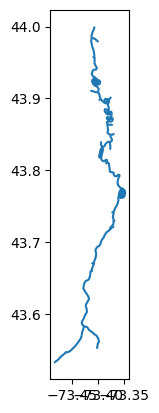

In [ ]:
main_nhd.plot()

In [ ]:
test = obs['fish']
test = test[:10]
for i, row in test.iterrows():
  print(row['uid'], row['ReachCode']==' ')

1024225435 True
1068828 False
1076016 False
1099976968 False
1100492 False
1143545878 False
1146196 False
1152389 False
1152995 False
1154587 False


In [ ]:
nldi = NLDI()
us_flowlines = nldi.navigate_byid(
  fsource="comid",
  fid=int("10314404"),
  navigation="upstreamTributaries",
  source="flowlines",
  distance=1000,
)

In [ ]:
us_flowlines

,geometry,nhdplus_comid
0,"LINESTRING (-73.40029 43.56888, -73.40096 43.5...",10314404
1,"LINESTRING (-73.3711 43.62493, -73.37188 43.62...",10312692
2,"LINESTRING (-73.3428 43.62648, -73.3445 43.626...",10312668
3,"LINESTRING (-73.33649 43.69862, -73.33828 43.6...",10312670
4,"LINESTRING (-73.2925 43.60311, -73.29307 43.60...",10312666
...,...,...
96,"LINESTRING (-73.14036 43.44188, -73.14036 43.4...",10313418
97,"LINESTRING (-73.09754 43.51427, -73.09732 43.5...",10312540
98,"LINESTRING (-73.10816 43.52145, -73.10879 43.5...",10312522
99,"LINESTRING (-73.17903 43.75147, -73.18374 43.7...",10312878


In [ ]:
# for unique lakes, trace upstream, count upstream species, find shortest distance

,uid,sci_name,obs_date,lat_dec,lon_dec,source,taxon,geometry,index_right,FID,...,AreaSqKm,Elevation,ReachCode,FType,FCode,Shape_Leng,Shape_Area,Area_Acres,P_COMID,distances
0,1829335757,Osmerus mordax,2001-01-01 00:00:00,46.670300,-90.862900,GBIF,fish,POINT (-254203.773 5215975.314),NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1829392290,Osmerus mordax,1996-01-01 00:00:00,44.900500,-87.056500,GBIF,fish,POINT (21826.616 4989770.402),NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1829368049,Osmerus mordax,1998-01-01 00:00:00,43.486700,-76.661700,GBIF,fish,POINT (850821.967 4824013.625),NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,urn:USGS:NAS:1553987,Neogobius melanostomus,2010-03-26 00:00:00,42.501390,-82.536940,GLANSIS,fish,POINT (373717.034 4706591.878),NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,urn:USGS:NAS:1402744,Neogobius melanostomus,2015-09-01 00:00:00,41.693810,-83.435170,GLANSIS,fish,POINT (297353.957 4618646.531),NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15879,795722,Neogobius melanostomus,2000-06-29 00:00:00,43.111667,-83.523333,MISIN,fish,POINT (294695.654 4776306.037),NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15880,4416863101,Neogobius melanostomus,2023-09-19 00:00:00,43.890675,-77.216086,GBIF,fish,POINT (803937.25 4866693.657),NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15881,1829369195,Neogobius melanostomus,2012-01-01 00:00:00,45.552700,-83.997900,GBIF,fish,POINT (266004.195 5048723.591),NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15882,1829401997,Osmerus mordax,2010-01-01 00:00:00,45.552800,-83.997900,GBIF,fish,POINT (266004.611 5048734.7),NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
sj

,uid,sci_name,obs_date,lat_dec,lon_dec,source,taxon,geometry,index_right,FID,...,AreaSqKm,Elevation,ReachCode,FType,FCode,Shape_Leng,Shape_Area,Area_Acres,P_COMID,distances
0,1829335757,Osmerus mordax,2001-01-01 00:00:00,46.670300,-90.862900,GBIF,fish,POINT (-90.8629 46.6703),627,627,...,0.029999999999999999,0,09020302001139,390,39004,0.0083891629692399994,0.0000035993693199700001,7.41315985,0,3.600128
1,1829392290,Osmerus mordax,1996-01-01 00:00:00,44.900500,-87.056500,GBIF,fish,POINT (-87.0565 44.9005),627,627,...,0.029999999999999999,0,09020302001139,390,39004,0.0083891629692399994,0.0000035993693199700001,7.41315985,0,7.788964
2,1829368049,Osmerus mordax,1998-01-01 00:00:00,43.486700,-76.661700,GBIF,fish,POINT (-76.6617 43.4867),627,627,...,0.029999999999999999,0,09020302001139,390,39004,0.0083891629692399994,0.0000035993693199700001,7.41315985,0,18.133405
3,urn:USGS:NAS:1553987,Neogobius melanostomus,2010-03-26 00:00:00,42.501390,-82.536940,GLANSIS,fish,POINT (-82.53694 42.50139),627,627,...,0.029999999999999999,0,09020302001139,390,39004,0.0083891629692399994,0.0000035993693199700001,7.41315985,0,12.891290
4,urn:USGS:NAS:1402744,Neogobius melanostomus,2015-09-01 00:00:00,41.693810,-83.435170,GLANSIS,fish,POINT (-83.43517 41.69381),627,627,...,0.029999999999999999,0,09020302001139,390,39004,0.0083891629692399994,0.0000035993693199700001,7.41315985,0,12.460268
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15879,795722,Neogobius melanostomus,2000-06-29 00:00:00,43.111667,-83.523333,MISIN,fish,POINT (-83.52333 43.11167),627,627,...,0.029999999999999999,0,09020302001139,390,39004,0.0083891629692399994,0.0000035993693199700001,7.41315985,0,11.741249
15880,4416863101,Neogobius melanostomus,2023-09-19 00:00:00,43.890675,-77.216086,GBIF,fish,POINT (-77.21609 43.89068),627,627,...,0.029999999999999999,0,09020302001139,390,39004,0.0083891629692399994,0.0000035993693199700001,7.41315985,0,17.499725
15881,1829369195,Neogobius melanostomus,2012-01-01 00:00:00,45.552700,-83.997900,GBIF,fish,POINT (-83.9979 45.5527),627,627,...,0.029999999999999999,0,09020302001139,390,39004,0.0083891629692399994,0.0000035993693199700001,7.41315985,0,10.517925
15882,1829401997,Osmerus mordax,2010-01-01 00:00:00,45.552800,-83.997900,GBIF,fish,POINT (-83.9979 45.5528),627,627,...,0.029999999999999999,0,09020302001139,390,39004,0.0083891629692399994,0.0000035993693199700001,7.41315985,0,10.517903


In [ ]:
# is pt within rad of a flowline? if so, or if inlake=True, get comid of nearest flowline segment
nldi = NLDI()
nhdp_mr = WaterData("nhdflowline_network")
comid_closest = nldi.comid_byloc(coords, crs)

def flwcheck(row):
  point = shapely.Point(row['lon_dec'], row['lat_dec'])
  try:
    wb_rad = nhdp_wb.bydistance(point.coords[0], rad) # dist is in meters, default crs 4326
    comid = wb_rad.iloc[0]['comid']
    gnisid = wb_rad.iloc[0]['gnis_id']
    nrows = wb_rad.shape[0] > 0 # are there flowlines within 500 m
    # do not flag as inlake if the lake is a Great Lake
    if gnisid in GL_gnisid:
      nrows = False
      comid = None
  except:
    nrows = False
    comid = None
  row['inlake'] = nrows
  row['lake_comid'] = comid
  return row

In [ ]:
nhdp_wb = WaterData("nhdwaterbody")
wb_id = nhdp_wb.byid("comid", 6646370) # dist is in meters, default crs 4326

<Axes: >

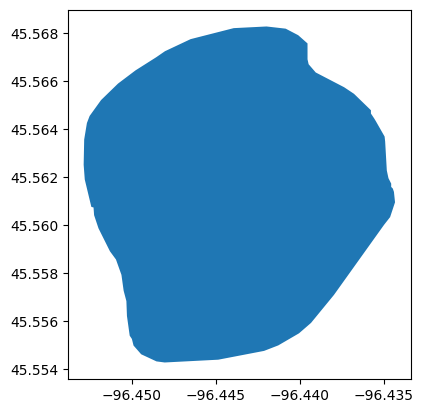

In [ ]:
wb_id.plot()

In [ ]:
start = timer()

for k in my_vars:
  #outfile = os.path.join(cwd, k + '_obs_allsources_' + datetime.date.today().strftime('%Y%m%d') + '.csv')
  outfile = '/content/drive/MyDrive/iedrr/speciesobs_20250118/'+k+'_obs_allsources_20250118.csv'
  df = pd.read_csv(outfile)
  df = df.apply(lakecheck, axis=1)
  obs[k] = df
  print(k, 'complete')

end = timer()
runtime = time.strftime('%H:%M:%S', time.gmtime(end - start))
print("runtime ",runtime)

In [ ]:
nldi = NLDI()
nhdp_mr = WaterData("nhdflowline_network")
# create a point
#eck4 = "+proj=eck4 +lon_0=0 +x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs"
crs = CRS.from_user_input(4326)
coords = (-119.60020, 37.73787)

# now figure out the nearest stream segment ID to our point
comid_closest = nldi.comid_byloc(coords, crs)
point_row = comid_closest.iloc[0]
measure = point_row['measure']
measure = float(measure)
row_seg = nhdp_mr.byid("comid", point_row['comid'])
length = row_seg['lengthkm']
print(length[0])
downlen = length[0]*measure/100
print(downlen)

KeyboardInterrupt: 

In [ ]:
measure = float(measure)
print(type(measure))

<class 'float'>


In [ ]:
point_row

,0
geometry,POINT (-119.60015528122153 37.7378901641063)
identifier,
navigation,https://api.water.usgs.gov/nldi/linked-data/co...
measure,35.51299639494459
reachcode,18040008000825
name,
source,indexed
sourceName,Automatically indexed by the NLDI
comid,21609461
type,hydrolocation


In [ ]:

# nldi navigation options: upstreamMain, upstreamTributaries, downstreamMain, downstreamDiversions
nldi = NLDI()

crs = CRS.from_user_input(4326)
coords = (-119.60020, 37.73787)

# now figure out the nearest stream segment ID to our point
comid_closest = nldi.comid_byloc(coords, crs)
print(comid_closest.comid.values[0])
# get upstream flowlines from nearest stream segment
yose_us_flowlines = nldi.navigate_byid(
    fsource="comid",
    fid=comid_closest.comid.values[0],
    navigation="upstreamTributaries",
    source="flowlines",
    distance=1000,
)

yose_usmain_flowlines = nldi.navigate_byid(
    fsource="comid",
    fid=comid_closest.comid.values[0],
    navigation="upstreamMain",
    source="flowlines",
    distance=1000,
)

21609461


In [ ]:
yose_trib = gpd.GeoDataFrame(yose_us_flowlines)
yose_main = gpd.GeoDataFrame(yose_usmain_flowlines)

In [ ]:
yose_main

,geometry,nhdplus_comid
0,"LINESTRING (-119.59985 37.73964, -119.60023 37...",21609461
1,"LINESTRING (-119.59501 37.74159, -119.59568 37...",21609443


In [ ]:
values_present = yose_trib['nhdplus_comid'].isin(yose_main['nhdplus_comid'])

In [ ]:
yose_trib[values_present]

,geometry,nhdplus_comid
0,"LINESTRING (-119.59985 37.73964, -119.60023 37...",21609461
1,"LINESTRING (-119.59501 37.74159, -119.59568 37...",21609443


In [ ]:
#ax = yose_trib.plot(facecolor="none", edgecolor="k", figsize=(8, 8))

#yose_trib.plot(ax=ax, lw=3, color="r", zorder=2, label="Main")
yose_main.plot(ax=ax, lw=1, color='b', zorder=1, label="Tributaries")

<Axes: >

In [ ]:
nldi = NLDI()

# create a point
#eck4 = "+proj=eck4 +lon_0=0 +x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs"
crs = CRS.from_user_input(4326)
coords = (-119.60020, 37.73787)

# now figure out the nearest stream segment ID to our point
comid_closest = nldi.comid_byloc(coords, crs)


In [ ]:
comid_closest

,geometry,identifier,navigation,measure,reachcode,name,source,sourceName,comid,type,uri
0,POINT (-119.60014 37.73768),,https://api.water.usgs.gov/nldi/linked-data/co...,28.09281468300957,18040008000825,,indexed,Automatically indexed by the NLDI,21609461,hydrolocation,


In [ ]:
yose_pkg = gpd.GeoDataFrame(pd.concat([yose_us_flowlines, yose_ds_flowlines], ignore_index=True))

<Axes: >

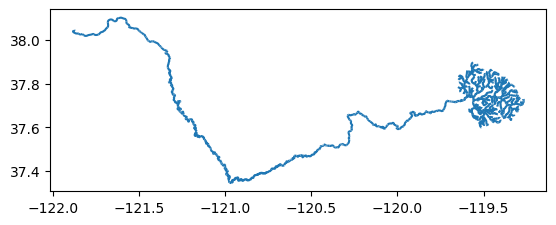

In [ ]:
yose_pkg.plot()

In [ ]:
column_list = yose_pkg.columns.tolist()
print(column_list)

['geometry', 'nhdplus_comid']


In [ ]:
# find upstream gages
yose_us_gages = nldi.navigate_byid(
    fsource="comid",
    fid=comid_closest.comid.values[0],
    navigation="upstreamTributaries",
    source="nwissite",
    distance=1000,
)

# downstream gages
yose_ds_gages = nldi.navigate_byid(
    fsource="comid",
    fid=comid_closest.comid.values[0],
    navigation="downstreamMain",
    source="nwissite",
    distance=1000,
)

<Axes: >

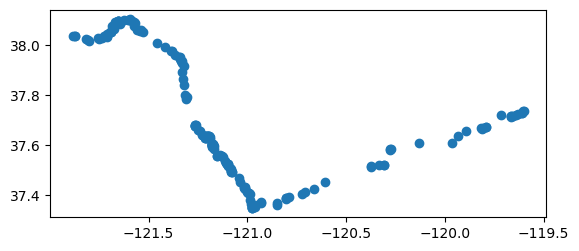

In [ ]:
yose_ds_gages.plot()

In [ ]:
# snap points to nearest line if within a km of a flowline or waterbody
nhdp_mr = WaterData("nhdflowline_network")
comid_closest = nldi.comid_byloc(coords, crs)
flw_closest = nhdp_mr.byid("comid", comid_closest.comid.values[0])

In [ ]:
flw_closest['wbareacomi']

,wbareacomi
0,0


In [ ]:
x = sorted(flw_closest.columns)
for item in x:
  print(item)

arbolatesu
areasqkm
comid
divdasqkm
divergence
dndraincou
dnhydroseq
dnlevel
dnlevelpat
dnminorhyd
elevfixed
enabled
fcode
fdate
flowdir
frommeas
fromnode
ftype
geometry
gnis_id
gnis_name
hwnodesqkm
hwtype
hydroseq
lakefract
lengthkm
levelpathi
maxelevraw
maxelevsmo
minelevraw
minelevsmo
pathlength
pathtimema
qa_01
qa_02
qa_03
qa_04
qa_05
qa_06
qa_07
qa_08
qa_09
qa_10
qa_11
qa_12
qa_ma
qc_01
qc_02
qc_03
qc_04
qc_05
qc_06
qc_07
qc_08
qc_09
qc_10
qc_11
qc_12
qc_ma
qe_01
qe_02
qe_03
qe_04
qe_05
qe_06
qe_07
qe_08
qe_09
qe_10
qe_11
qe_12
qe_ma
rareahload
reachcode
resolution
rpuid
rtndiv
shape_length
slope
slopelenkm
startflag
streamcalc
streamleve
streamorde
surfarea
terminalfl
terminalpa
tidal
tomeas
tonode
totdasqkm
totma
uphydroseq
uplevelpat
va_01
va_02
va_03
va_04
va_05
va_06
va_07
va_08
va_09
va_10
va_11
va_12
va_ma
vc_01
vc_02
vc_03
vc_04
vc_05
vc_06
vc_07
vc_08
vc_09
vc_10
vc_11
vc_12
vc_ma
ve_01
ve_02
ve_03
ve_04
ve_05
ve_06
ve_07
ve_08
ve_09
ve_10
ve_11
ve_12
ve_ma
vpuid
vpuin
vp

In [ ]:


# Create a point
#point = gpd.read_file(r"C:\GIS\data\testdata\1000points.geojson")

point = Point(coords)
p1, p2 = nearest_points(flw_closest.geometry, point)
p1 = p1.set_crs(crs)
# convert to UTM
gdfp = gpd.GeoDataFrame(geometry=[point], crs="EPSG:4326")  # Assuming the original CRS is EPSG:4326
#gdfnp = gpd.GeoDataFrame(geometry=[p1], crs="EPSG:4326")  # Assuming the original CRS is EPSG:4326


In [ ]:

utm = flw_closest.estimate_utm_crs()
dist = p1.to_crs(utm).distance(gdfp.to_crs(utm))
dist
# keep it if it's within a kilometer of a flowline
if dist < 1000:
  newcoords = p1.geometry

,0
0,4.061502


In [ ]:
# is there a lake within a km
from pynhd import NHD
nhd = NHD("flowline_mr")

In [ ]:
main_nhd = nhd.byids("reachcode", 4150310009534)

InputValueError: Given field is invalid. Valid options are:
FTYPE
Shape_Length
LENGTHKM
Resolution
WBAREA_PERMANENT_IDENTIFIER
PERMANENT_IDENTIFIER
Shape
REACHCODE
FDATE
FType
GNIS_ID
FlowDir
OBJECTID
GNIS_NAME
FCode
FCODE
FLOWDIR
GLOBALID
RESOLUTION
*

In [ ]:

main_nhd = nhd.byids("reachcode", flw_main.index)

nhd3d = HP3D("hydrolocation_reach")
flw = nhd3d.byids(point, distance=1000)
flw.explore()

In [ ]:
flw[flw['featuretype'] > 1].shape[0]

9

In [ ]:
sj = gpd.sjoin_nearest(left_df=gdfp, right_df=flw, how="left",  distance_col="distances")


/usr/local/lib/python3.11/dist-packages/geopandas/array.py:403: UserWarning: Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  warnings.warn(


In [ ]:
sj

,geometry,index_right,OBJECTID,id3dhp,featuredate,mainstemid,gnisid,gnisidlabel,featuretype,featuretypelabel,areasqkm,edhuniqueid,workunitid,SHAPE_Length,SHAPE_Area,distances
0,POINT (-119.6002 37.73787),12,7101337,OGIMS,1694649600000,None,None,None,1,River,2.071,157076898,NHD,222600.804435,3.934859e+06,30.221869


In [ ]:
# create a 1 meter buffer around snapped point

# split stream segments

# drop the "loose ends" on either extent (upstream or downstream) of first/last gage

# sum cumulative length of segments

# include riparian wetlands?


In [ ]:

# Reproject to a new CRS
gdf = gdf.to_crs("EPSG:3857")

# Access the transformed point
transformed_point = gdf.geometry[0]
# create a uniqueid
#point["pointid"] = range(point.shape[0])




if p1 is not None:
  newcoords = p1.geometry


In [ ]:

# create a uniqueid
point["pointid"] = range(point.shape[0])

p1, p2 = nearest_points(flw_closest.geometry, point)

if p1 is not None:
  newcoords = p1.geometry


In [ ]:
newcoords

,geometry
0,POINT (-119.60015 37.73787)


In [ ]:
utm = flw_closest.estimate_utm_crs()
gdfl.to_crs(utm).distance(gdfp.to_crs(utm))

In [ ]:
#Create unique id
point["pointid"] = range(point.shape[0])

line["linegeom"] = line.geometry #Save the line geometry or it is lost in the spatial join

sj = gpd.sjoin_nearest(left_df=point, right_df=line, how="left", max_distance=100)

In [ ]:
ax = yose_pkg.plot(facecolor="none", edgecolor="k", figsize=(8, 8))
st_all.plot(
    ax=ax, label="USGS stations", marker="*", markersize=300, zorder=4, color="b"
)
st_d20.plot(
    ax=ax,
    label="USGS stations up to 20 km",
    marker="v",
    markersize=100,
    zorder=5,
    color="darkorange",
)
pp.plot(
    ax=ax, label="HUC12 pour points", marker="o", markersize=50, color="k", zorder=3
)
flw_main.plot(ax=ax, lw=3, color="r", zorder=2, label="Main")
flw_trib.plot(ax=ax, lw=1, zorder=1, label="Tributaries")
ax.legend(loc="best")
ax.set_aspect("auto")
ax.figure.set_dpi(100)
ax.figure.savefig("../_static/nhdplus_navigation.png", bbox_inches="tight", dpi=100)

In [ ]:
nldi = NLDI()
station_id = "01031500"

basin = nldi.get_basins(station_id)

In [ ]:
hr = NHD("flowline_hr")
nhdp_hr = hr.bygeom(basin.geometry[0].bounds)


/usr/local/lib/python3.11/dist-packages/geopandas/geoseries.py:720: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  val = getattr(super(), mtd)(*args, **kwargs)


In [ ]:
mr = NHD("flowline_mr")
nhdp_mr = mr.bygeom(basin.geometry[0].bounds)

/usr/local/lib/python3.11/dist-packages/geopandas/geoseries.py:720: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  val = getattr(super(), mtd)(*args, **kwargs)


In [ ]:
mr = WaterData("nhdflowline_network")
nhdp_mr = mr.bybox(basin.geometry[0].bounds)

# snap point to the closest feature ID using nldi
eck4 = "+proj=eck4 +lon_0=0 +x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs"
coords = (-5727797.427596455, 5584066.49330473)
rad = 5e3
flw_rad = mr.bydistance(coords, rad, loc_crs=eck4)
flw_rad = flw_rad.to_crs(eck4)

comid_closest = nldi.comid_byloc(coords, eck4)
flw_closest = mr.byid("comid", comid_closest.comid.values[0])

/usr/local/lib/python3.11/dist-packages/geopandas/geoseries.py:720: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  val = getattr(super(), mtd)(*args, **kwargs)


In [ ]:
yose_ds_flowlines

,geometry,nhdplus_comid
0,"LINESTRING (-69.58493 45.27063, -69.58486 45.2...",1721977
1,"LINESTRING (-69.57876 45.25565, -69.57898 45.2...",1721981
2,"LINESTRING (-69.57898 45.25506, -69.57885 45.2...",1721989
3,"LINESTRING (-69.57478 45.25233, -69.5717 45.25...",1722001
4,"LINESTRING (-69.56704 45.25121, -69.56652 45.2...",1722005
...,...,...
135,"LINESTRING (-68.83692 44.63802, -68.83695 44.6...",1737050
136,"LINESTRING (-68.83695 44.6375, -68.83771 44.63...",1737082
137,"LINESTRING (-68.83445 44.60789, -68.83334 44.6...",1737106
138,"LINESTRING (-68.82341 44.59628, -68.8235 44.59...",1737118


In [ ]:
# make a list of all the comids we've identified:
all_comids = pd.concat([yose_us_flowlines['nhdplus_comid'], yose_ds_flowlines['nhdplus_comid']]).tolist()


In [ ]:
nhd.subset_nhdplus(comids=comids, layer='nhdflowline')


In [ ]:
hr = NHDPlusHR("flowline")
nhdp_hr = hr.bygeom(basin.geometry[0].bounds)

# snap point to the closest feature ID using nldi
eck4 = "+proj=eck4 +lon_0=0 +x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs"
coords = (-5727797.427596455, 5584066.49330473)
rad = 5e3
flw_rad = mr.bydistance(coords, rad, loc_crs=eck4)
flw_rad = flw_rad.to_crs(eck4)
flw_closest = wd.byid("comid", comid_closest.comid.values[0])

/usr/local/lib/python3.11/dist-packages/geopandas/geoseries.py:720: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  val = getattr(super(), mtd)(*args, **kwargs)


In [ ]:
mr

Connected to the WaterData web service on GeoServer:
URL: https://api.water.usgs.gov/geoserver/wmadata/ows
Version: 2.0.0
Layer: wmadata:nhdflowline_network
Output Format: application/json
Output CRS: 4326

In [ ]:
comid_closest

,geometry,identifier,navigation,measure,reachcode,name,source,sourceName,comid,type,uri
0,POINT (-69.58376 45.26712),,https://api.water.usgs.gov/nldi/linked-data/co...,82.05854546491726,01020004000264,,indexed,Automatically indexed by the NLDI,1721977,hydrolocation,


In [ ]:
wd = WaterData("nhdflowline_network")
flw_closest = wd.byid("comid", comid_closest.comid.values[0])

In [ ]:
from __future__ import annotations

from pathlib import Path

import geopandas as gpd
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import pynhd as nhd
from pynhd import NLDI, NHDPlusHR, WaterData

In [ ]:
nldi = NLDI()
station_id = "01031500"

basin = nldi.get_basins(station_id)

#We can get other USGS stations upstream (or downstream) of the station and even set a distance limit (in km):
st_all = nldi.navigate_byid(
    fsource="nwissite",
    fid=f"USGS-{station_id}",
    navigation="upstreamTributaries",
    source="nwissite",
    distance=1000,
)